In [4]:
# ============================================================
# MLBFD — PHASE 2B, CELL 1
# MEGA DATASET TRAINING
# Multi-Layer Behavioral Fraud Detection System
# ============================================================
# Setup + Mount Google Drive + Load All Datasets
# ============================================================

!pip install xgboost shap imbalanced-learn tensorflow --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve,
                             average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from imblearn.over_sampling import SMOTE
import xgboost as xgb

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(f"{'='*60}")
print(f"  MLBFD — MEGA DATASET TRAINING")
print(f"  Phase 2B: Multi-Source Model Training")
print(f"{'='*60}")
print("✅ All libraries loaded\n")

# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/MLBFD_Datasets/'

# ============================================================
# CHECK WHAT FILES ARE AVAILABLE
# ============================================================
print(f"\n{'='*60}")
print("📂 CHECKING UPLOADED DATASETS")
print(f"{'='*60}")

expected_files = {
    # Tier 1
    'PS_20174392719_1491204439457_log.csv': 'PaySim Mobile Money',
    'train_transaction.csv': 'IEEE-CIS Fraud (Transactions)',
    'train_identity.csv': 'IEEE-CIS Fraud (Identity)',
    # Tier 2
    'Base.csv': 'Bank Account Fraud (BAF)',
    'AIML Dataset.csv': 'AIML Fraud Detection',
    'synthetic_mobile_money_transaction_dataset.csv': 'Synthetic Mobile Money 2024',
    # Phase 1
    'mlbfd_ml_ready.csv': 'MLBFD ML-Ready (Phase 1)',
    'mlbfd_user_profiles.csv': 'MLBFD User Profiles',
    'creditcard.csv': 'Credit Card Fraud (Kaggle)',
}

available_files = {}
missing_files = []

for filename, description in expected_files.items():
    filepath = DRIVE_PATH + filename
    if os.path.exists(filepath):
        size_mb = os.path.getsize(filepath) / (1024*1024)
        available_files[filename] = filepath
        print(f"  ✅ {description:40s} | {filename} ({size_mb:.1f} MB)")
    else:
        missing_files.append(filename)
        print(f"  ❌ {description:40s} | {filename} — NOT FOUND")

print(f"\n📊 Found: {len(available_files)}/{len(expected_files)} datasets")
if missing_files:
    print(f"⚠️  Missing: {len(missing_files)} files (will continue without them)")
    print(f"   Missing: {missing_files}")
print(f"\n→ Run Cell 2 to load and merge all datasets")

  MLBFD — MEGA DATASET TRAINING
  Phase 2B: Multi-Source Model Training
✅ All libraries loaded

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📂 CHECKING UPLOADED DATASETS
  ❌ PaySim Mobile Money                      | PS_20174392719_1491204439457_log.csv — NOT FOUND
  ❌ IEEE-CIS Fraud (Transactions)            | train_transaction.csv — NOT FOUND
  ❌ IEEE-CIS Fraud (Identity)                | train_identity.csv — NOT FOUND
  ❌ Bank Account Fraud (BAF)                 | Base.csv — NOT FOUND
  ❌ AIML Fraud Detection                     | AIML Dataset.csv — NOT FOUND
  ❌ Synthetic Mobile Money 2024              | synthetic_mobile_money_transaction_dataset.csv — NOT FOUND
  ❌ MLBFD ML-Ready (Phase 1)                 | mlbfd_ml_ready.csv — NOT FOUND
  ❌ MLBFD User Profiles                      | mlbfd_user_profiles.csv — NOT FOUND
  ❌ Credit Card Fraud (Kaggle)               | creditcard.csv — NOT FOUND

📊 Fo

In [2]:
# Find where Tier1 files are in Google Drive
import os

# Search for the PaySim file (unique name, easy to find)
target = 'PS_20174392719_1491204439457_log.csv'

print("🔍 Searching for Tier1 files...\n")

for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    for f in files:
        if f == target or f == 'train_transaction.csv':
            full_path = os.path.join(root, f)
            folder = os.path.dirname(full_path)
            print(f"📂 FOUND: {full_path}")
            print(f"📁 FOLDER: {folder}")

print("\n✅ Copy the FOLDER path and paste it here!")

🔍 Searching for Tier1 files...

📂 FOUND: /content/drive/MyDrive/Tier1/PS_20174392719_1491204439457_log.csv
📁 FOLDER: /content/drive/MyDrive/Tier1
📂 FOUND: /content/drive/MyDrive/Tier1/train_transaction.csv
📁 FOLDER: /content/drive/MyDrive/Tier1

✅ Copy the FOLDER path and paste it here!


In [3]:
# Check ALL folders - Tier1, Tier2, Phase1
import os

print("🔍 Searching for ALL dataset folders...\n")

search_files = {
    'Tier1': ['PS_20174392719_1491204439457_log.csv', 'train_transaction.csv', 'train_identity.csv'],
    'Tier2': ['Base.csv', 'AIML Dataset.csv', 'synthetic_mobile_money_transaction_dataset.csv'],
    'Phase1': ['mlbfd_ml_ready.csv', 'creditcard.csv', 'mlbfd_user_profiles.csv']
}

found_paths = {}

for root, dirs, files in os.walk('/content/drive/MyDrive/'):
    for f in files:
        for tier, tier_files in search_files.items():
            if f in tier_files:
                folder = os.path.dirname(os.path.join(root, f))
                if tier not in found_paths:
                    found_paths[tier] = folder
                print(f"  ✅ [{tier}] {f}")
                print(f"     → {os.path.join(root, f)}")

print(f"\n{'='*50}")
print("📁 FOLDER SUMMARY:")
print(f"{'='*50}")
for tier, path in found_paths.items():
    print(f"  {tier}: {path}")

not_found = [t for t in search_files if t not in found_paths]
if not_found:
    print(f"\n  ⏳ Still uploading: {not_found}")
else:
    print(f"\n  🎉 ALL FOLDERS READY!")

🔍 Searching for ALL dataset folders...

  ✅ [Tier1] PS_20174392719_1491204439457_log.csv
     → /content/drive/MyDrive/Tier1/PS_20174392719_1491204439457_log.csv
  ✅ [Tier1] train_identity.csv
     → /content/drive/MyDrive/Tier1/train_identity.csv
  ✅ [Tier1] train_transaction.csv
     → /content/drive/MyDrive/Tier1/train_transaction.csv
  ✅ [Tier2] AIML Dataset.csv
     → /content/drive/MyDrive/Tier2/AIML Dataset.csv
  ✅ [Tier2] Base.csv
     → /content/drive/MyDrive/Tier2/Base.csv
  ✅ [Tier2] synthetic_mobile_money_transaction_dataset.csv
     → /content/drive/MyDrive/Tier2/synthetic_mobile_money_transaction_dataset.csv
  ✅ [Phase1] mlbfd_user_profiles.csv
     → /content/drive/MyDrive/MLBFD_Phase1/Data/mlbfd_user_profiles.csv
  ✅ [Phase1] mlbfd_ml_ready.csv
     → /content/drive/MyDrive/MLBFD_Phase1/Data/mlbfd_ml_ready.csv

📁 FOLDER SUMMARY:
  Tier1: /content/drive/MyDrive/Tier1
  Tier2: /content/drive/MyDrive/Tier2
  Phase1: /content/drive/MyDrive/MLBFD_Phase1/Data

  🎉 ALL FOLDERS

In [5]:
# ============================================================
# MLBFD — PHASE 2B, CELL 1 (UPDATED WITH CORRECT PATHS)
# MEGA DATASET TRAINING
# Multi-Layer Behavioral Fraud Detection System
# ============================================================

!pip install xgboost shap imbalanced-learn tensorflow --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle
import os
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report, precision_recall_curve,
                             average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from imblearn.over_sampling import SMOTE
import xgboost as xgb

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(f"{'='*60}")
print(f"  MLBFD — MEGA DATASET TRAINING")
print(f"  Phase 2B: Multi-Source Model Training")
print(f"{'='*60}")
print("✅ All libraries loaded\n")

# ============================================================
# MOUNT GOOGLE DRIVE
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# EXACT FILE PATHS
# ============================================================
TIER1_PATH = '/content/drive/MyDrive/Tier1/'
TIER2_PATH = '/content/drive/MyDrive/Tier2/'
PHASE1_PATH = '/content/drive/MyDrive/MLBFD_Phase1/Data/'

datasets_to_load = {
    # Tier 1
    'PaySim Mobile Money':       TIER1_PATH + 'PS_20174392719_1491204439457_log.csv',
    'IEEE-CIS Transactions':     TIER1_PATH + 'train_transaction.csv',
    # Tier 2
    'Bank Account Fraud (BAF)':  TIER2_PATH + 'Base.csv',
    'AIML Fraud Detection':      TIER2_PATH + 'AIML Dataset.csv',
    'Synthetic Mobile Money':    TIER2_PATH + 'synthetic_mobile_money_transaction_dataset.csv',
    # Phase 1
    'MLBFD Phase 1 ML-Ready':    PHASE1_PATH + 'mlbfd_ml_ready.csv',
}

# ============================================================
# VERIFY ALL FILES
# ============================================================
print(f"\n{'='*60}")
print("📂 VERIFYING ALL DATASETS")
print(f"{'='*60}")

all_found = True
for name, path in datasets_to_load.items():
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024*1024)
        print(f"  ✅ {name:35s} | {size_mb:>8.1f} MB")
    else:
        print(f"  ❌ {name:35s} | NOT FOUND")
        all_found = False

if all_found:
    print(f"\n🎉 ALL 6 DATASETS FOUND — READY TO TRAIN!")
else:
    print(f"\n⚠️  Some files missing — will continue with available files")

print(f"\n→ Run Cell 2 to load and map all datasets")

  MLBFD — MEGA DATASET TRAINING
  Phase 2B: Multi-Source Model Training
✅ All libraries loaded

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📂 VERIFYING ALL DATASETS
  ✅ PaySim Mobile Money                 |    470.7 MB
  ✅ IEEE-CIS Transactions               |    651.7 MB
  ✅ Bank Account Fraud (BAF)            |    203.5 MB
  ✅ AIML Fraud Detection                |    470.7 MB
  ✅ Synthetic Mobile Money              |    149.3 MB
  ✅ MLBFD Phase 1 ML-Ready              |    178.2 MB

🎉 ALL 6 DATASETS FOUND — READY TO TRAIN!

→ Run Cell 2 to load and map all datasets


In [6]:
# ============================================================
# MLBFD — PHASE 2B, CELL 2
# LOAD ALL DATASETS + SMART COLUMN MAPPING
# ============================================================

def load_and_map_dataset(filepath, dataset_name):
    """Load a dataset and map it to our standard fraud detection format"""

    try:
        df = pd.read_csv(filepath, low_memory=False)
        print(f"\n{'─'*60}")
        print(f"📂 {dataset_name}")
        print(f"   Rows: {len(df):,} | Columns: {len(df.columns)}")
        print(f"   Columns: {list(df.columns[:10])}{'...' if len(df.columns) > 10 else ''}")
    except Exception as e:
        print(f"❌ Error loading {dataset_name}: {e}")
        return None

    mapped = pd.DataFrame()

    # ============================================================
    # DATASET: PaySim Mobile Money
    # ============================================================
    if 'isFraud' in df.columns and 'nameOrig' in df.columns:
        print(f"   🔍 Detected: PaySim Mobile Money")
        mapped['amount'] = df['amount']
        mapped['is_fraud'] = df['isFraud']
        mapped['hour'] = df['step'] % 24
        mapped['balance_before'] = df['oldbalanceOrg']
        mapped['balance_after'] = df['newbalanceOrig']
        mapped['balance_dest_before'] = df['oldbalanceDest']
        mapped['balance_dest_after'] = df['newbalanceDest']
        mapped['balance_change'] = df['newbalanceOrig'] - df['oldbalanceOrg']
        mapped['balance_change_ratio'] = np.where(
            df['oldbalanceOrg'] > 0,
            (df['oldbalanceOrg'] - df['newbalanceOrig']) / df['oldbalanceOrg'],
            0
        )
        mapped['dest_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']
        mapped['is_cash_out'] = (df['type'] == 'CASH_OUT').astype(int)
        mapped['is_transfer'] = (df['type'] == 'TRANSFER').astype(int)
        mapped['is_payment'] = (df['type'] == 'PAYMENT').astype(int)
        mapped['is_debit'] = (df['type'] == 'DEBIT').astype(int)
        mapped['is_cash_in'] = (df['type'] == 'CASH_IN').astype(int)
        mapped['source'] = 'paysim'

    # ============================================================
    # DATASET: IEEE-CIS Fraud Detection
    # ============================================================
    elif 'isFraud' in df.columns and 'TransactionAmt' in df.columns:
        print(f"   🔍 Detected: IEEE-CIS Fraud Detection")
        mapped['amount'] = df['TransactionAmt']
        mapped['is_fraud'] = df['isFraud']
        mapped['hour'] = (df['TransactionDT'] % 86400 / 3600).astype(int) % 24
        if 'card1' in df.columns: mapped['card_id'] = df['card1']
        if 'card4' in df.columns:
            le = LabelEncoder()
            mapped['card_type'] = le.fit_transform(df['card4'].fillna('unknown'))
        if 'card6' in df.columns:
            le = LabelEncoder()
            mapped['card_category'] = le.fit_transform(df['card6'].fillna('unknown'))
        if 'addr1' in df.columns: mapped['address_code'] = df['addr1'].fillna(0)
        if 'ProductCD' in df.columns:
            le = LabelEncoder()
            mapped['product_type'] = le.fit_transform(df['ProductCD'].fillna('unknown'))
        if 'DeviceType' in df.columns:
            le = LabelEncoder()
            mapped['device_type'] = le.fit_transform(df['DeviceType'].fillna('unknown'))
        if 'P_emaildomain' in df.columns:
            mapped['has_email'] = df['P_emaildomain'].notna().astype(int)
        for col in ['C1','C2','C3','C5','C6','C9','C13','C14']:
            if col in df.columns:
                mapped[f'count_{col.lower()}'] = df[col].fillna(0)
        for col in ['D1','D2','D3','D4','D10','D15']:
            if col in df.columns:
                mapped[f'delta_{col.lower()}'] = df[col].fillna(-1)
        mapped['source'] = 'ieee_cis'

    # ============================================================
    # DATASET: Bank Account Fraud (BAF)
    # ============================================================
    elif 'fraud_bool' in df.columns:
        print(f"   🔍 Detected: Bank Account Fraud (BAF)")
        mapped['is_fraud'] = df['fraud_bool']
        if 'income' in df.columns: mapped['amount'] = df['income']
        if 'name_email_similarity' in df.columns: mapped['name_email_sim'] = df['name_email_similarity']
        if 'customer_age' in df.columns: mapped['customer_age'] = df['customer_age']
        if 'days_since_request' in df.columns: mapped['days_since_request'] = df['days_since_request']
        if 'intended_balcon_amount' in df.columns: mapped['intended_balance'] = df['intended_balcon_amount']
        if 'zip_count_4w' in df.columns: mapped['zip_activity'] = df['zip_count_4w']
        if 'velocity_6h' in df.columns: mapped['velocity_6h'] = df['velocity_6h']
        if 'velocity_24h' in df.columns: mapped['velocity_24h'] = df['velocity_24h']
        if 'bank_branch_count_8w' in df.columns: mapped['branch_activity'] = df['bank_branch_count_8w']
        if 'date_of_birth_distinct_emails_4w' in df.columns: mapped['dob_emails'] = df['date_of_birth_distinct_emails_4w']
        if 'credit_risk_score' in df.columns: mapped['credit_risk'] = df['credit_risk_score']
        if 'phone_home_valid' in df.columns: mapped['phone_valid'] = df['phone_home_valid']
        if 'session_length_in_minutes' in df.columns: mapped['session_length'] = df['session_length_in_minutes']
        if 'device_os' in df.columns:
            le = LabelEncoder()
            mapped['device_os'] = le.fit_transform(df['device_os'].fillna('unknown').astype(str))
        mapped['hour'] = np.random.randint(0, 24, len(df))
        mapped['source'] = 'baf'

    # ============================================================
    # DATASET: AIML Fraud Detection (PaySim-like)
    # ============================================================
    elif 'isFraud' in df.columns and 'oldbalanceOrg' in df.columns:
        print(f"   🔍 Detected: AIML Fraud Detection")
        mapped['amount'] = df['amount']
        mapped['is_fraud'] = df['isFraud']
        mapped['hour'] = df['step'] % 24 if 'step' in df.columns else np.random.randint(0, 24, len(df))
        mapped['balance_before'] = df['oldbalanceOrg']
        mapped['balance_after'] = df['newbalanceOrig']
        mapped['balance_change'] = df['newbalanceOrig'] - df['oldbalanceOrg']
        mapped['balance_change_ratio'] = np.where(
            df['oldbalanceOrg'] > 0,
            (df['oldbalanceOrg'] - df['newbalanceOrig']) / df['oldbalanceOrg'],
            0
        )
        mapped['is_cash_out'] = (df['type'] == 'CASH_OUT').astype(int) if 'type' in df.columns else 0
        mapped['is_transfer'] = (df['type'] == 'TRANSFER').astype(int) if 'type' in df.columns else 0
        mapped['source'] = 'aiml'

    # ============================================================
    # DATASET: MLBFD Phase 1 ML-Ready
    # ============================================================
    elif 'is_fraud' in df.columns and 'amount_inr' in df.columns:
        print(f"   🔍 Detected: MLBFD Phase 1 ML-Ready")
        mapped['amount'] = df['amount_inr']
        mapped['is_fraud'] = df['is_fraud']
        mapped['hour'] = df['hour_ist'] if 'hour_ist' in df.columns else np.random.randint(0, 24, len(df))
        for col in df.select_dtypes(include=[np.number]).columns:
            if col not in ['is_fraud', 'amount_inr', 'hour_ist']:
                mapped[col] = df[col]
        mapped['source'] = 'mlbfd_phase1'

    # ============================================================
    # DATASET: Synthetic Mobile Money 2024
    # ============================================================
    elif 'Fraud' in df.columns or 'fraud' in df.columns:
        fraud_col = 'Fraud' if 'Fraud' in df.columns else 'fraud'
        print(f"   🔍 Detected: Synthetic Mobile Money 2024")
        mapped['is_fraud'] = df[fraud_col]
        for col in ['Amount', 'amount', 'TransactionAmount', 'transaction_amount']:
            if col in df.columns:
                mapped['amount'] = df[col]
                break
        if 'amount' not in mapped.columns:
            for col in df.columns:
                if df[col].dtype in ['float64', 'int64'] and col.lower() != fraud_col.lower():
                    mapped['amount'] = df[col]
                    break
        mapped['hour'] = np.random.randint(0, 24, len(df))
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for col in numeric_cols[:15]:
            if col.lower() not in [fraud_col.lower(), 'amount']:
                mapped[f'mm_{col.lower().replace(" ","_")}'] = df[col].fillna(0)
        mapped['source'] = 'mobile_money_2024'

    # ============================================================
    # GENERIC FALLBACK
    # ============================================================
    else:
        print(f"   🔍 Attempting auto-detection...")
        fraud_candidates = [c for c in df.columns if any(x in c.lower() for x in ['fraud', 'label', 'class', 'target'])]
        if not fraud_candidates:
            print(f"   ❌ Cannot find fraud label column. Skipping.")
            return None
        fraud_col = fraud_candidates[0]
        mapped['is_fraud'] = df[fraud_col].astype(int)
        amount_candidates = [c for c in df.columns if any(x in c.lower() for x in ['amount', 'amt', 'value', 'price'])]
        if amount_candidates:
            mapped['amount'] = df[amount_candidates[0]]
        mapped['hour'] = np.random.randint(0, 24, len(df))
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for col in numeric_cols[:20]:
            if col != fraud_col:
                mapped[f'auto_{col.lower().replace(" ","_")}'] = df[col].fillna(0)
        mapped['source'] = 'auto_detected'

    # ============================================================
    # POST-PROCESSING
    # ============================================================
    if mapped is not None and len(mapped) > 0:
        if 'is_fraud' in mapped.columns:
            mapped['is_fraud'] = mapped['is_fraud'].astype(int)
            mapped['is_fraud'] = mapped['is_fraud'].clip(0, 1)
        for col in mapped.columns:
            if mapped[col].dtype in ['float64', 'int64']:
                mapped[col] = mapped[col].fillna(0)

        fraud_count = mapped['is_fraud'].sum()
        fraud_pct = fraud_count / len(mapped) * 100
        print(f"   ✅ Mapped: {len(mapped):,} rows | {len(mapped.columns)} features")
        print(f"   🔴 Fraud: {fraud_count:,} ({fraud_pct:.2f}%) | 🟢 Legit: {len(mapped)-fraud_count:,} ({100-fraud_pct:.2f}%)")
        return mapped

    return None

# ============================================================
# LOAD ALL 6 DATASETS
# ============================================================
print(f"{'='*60}")
print("🔄 LOADING ALL 6 DATASETS")
print(f"{'='*60}")

all_datasets = []
dataset_stats = {}

for name, path in datasets_to_load.items():
    if os.path.exists(path):
        mapped = load_and_map_dataset(path, name)
        if mapped is not None and len(mapped) > 0:
            all_datasets.append(mapped)
            dataset_stats[name] = {
                'rows': len(mapped),
                'features': len(mapped.columns),
                'fraud': int(mapped['is_fraud'].sum()),
                'fraud_pct': float(mapped['is_fraud'].mean() * 100),
                'source': mapped['source'].iloc[0]
            }
    else:
        print(f"\n⏭️  Skipping: {name} (not found)")

# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*60}")
print(f"📊 LOADING COMPLETE")
print(f"{'='*60}")
print(f"   Datasets loaded: {len(all_datasets)}")
total_rows = sum(len(d) for d in all_datasets)
total_fraud = sum(d['is_fraud'].sum() for d in all_datasets)
print(f"   Total rows:      {total_rows:,}")
print(f"   Total fraud:     {total_fraud:,} ({total_fraud/total_rows*100:.2f}%)")
print(f"\n→ Run Cell 3 to merge into Mega-Dataset")

🔄 LOADING ALL 6 DATASETS

────────────────────────────────────────────────────────────
📂 PaySim Mobile Money
   Rows: 6,362,620 | Columns: 11
   Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud']...
   🔍 Detected: PaySim Mobile Money
   ✅ Mapped: 6,362,620 rows | 16 features
   🔴 Fraud: 8,213 (0.13%) | 🟢 Legit: 6,354,407 (99.87%)

────────────────────────────────────────────────────────────
📂 IEEE-CIS Transactions
   Rows: 590,540 | Columns: 394
   Columns: ['TransactionID', 'isFraud', 'TransactionDT', 'TransactionAmt', 'ProductCD', 'card1', 'card2', 'card3', 'card4', 'card5']...
   🔍 Detected: IEEE-CIS Fraud Detection
   ✅ Mapped: 590,540 rows | 24 features
   🔴 Fraud: 20,663 (3.50%) | 🟢 Legit: 569,877 (96.50%)

────────────────────────────────────────────────────────────
📂 Bank Account Fraud (BAF)
   Rows: 1,000,000 | Columns: 32
   Columns: ['fraud_bool', 'income', 'name_email_similarity', 'pr

In [3]:
# ============================================================
# MLBFD — PHASE 2B, CELL 2+3 COMBINED
# LOAD ALL DATASETS + MERGE INTO MEGA-DATASET
# ============================================================

# ============================================================
# PATHS (Already verified)
# ============================================================
TIER1_PATH = '/content/drive/MyDrive/Tier1/'
TIER2_PATH = '/content/drive/MyDrive/Tier2/'
PHASE1_PATH = '/content/drive/MyDrive/MLBFD_Phase1/Data/'

datasets_to_load = {
    'PaySim Mobile Money':       TIER1_PATH + 'PS_20174392719_1491204439457_log.csv',
    'IEEE-CIS Transactions':     TIER1_PATH + 'train_transaction.csv',
    'Bank Account Fraud (BAF)':  TIER2_PATH + 'Base.csv',
    'AIML Fraud Detection':      TIER2_PATH + 'AIML Dataset.csv',
    'Synthetic Mobile Money':    TIER2_PATH + 'synthetic_mobile_money_transaction_dataset.csv',
    'MLBFD Phase 1 ML-Ready':    PHASE1_PATH + 'mlbfd_ml_ready.csv',
}

# ============================================================
# SMART COLUMN MAPPER
# ============================================================
def load_and_map_dataset(filepath, dataset_name):
    try:
        df = pd.read_csv(filepath, low_memory=False)
        print(f"\n{'─'*60}")
        print(f"📂 {dataset_name}")
        print(f"   Rows: {len(df):,} | Columns: {len(df.columns)}")
    except Exception as e:
        print(f"❌ Error loading {dataset_name}: {e}")
        return None

    mapped = pd.DataFrame()

    # PaySim Mobile Money
    if 'isFraud' in df.columns and 'nameOrig' in df.columns:
        print(f"   🔍 Detected: PaySim Mobile Money")
        mapped['amount'] = df['amount']
        mapped['is_fraud'] = df['isFraud']
        mapped['hour'] = df['step'] % 24
        mapped['balance_before'] = df['oldbalanceOrg']
        mapped['balance_after'] = df['newbalanceOrig']
        mapped['balance_dest_before'] = df['oldbalanceDest']
        mapped['balance_dest_after'] = df['newbalanceDest']
        mapped['balance_change'] = df['newbalanceOrig'] - df['oldbalanceOrg']
        mapped['balance_change_ratio'] = np.where(
            df['oldbalanceOrg'] > 0,
            (df['oldbalanceOrg'] - df['newbalanceOrig']) / df['oldbalanceOrg'], 0)
        mapped['dest_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']
        mapped['is_cash_out'] = (df['type'] == 'CASH_OUT').astype(int)
        mapped['is_transfer'] = (df['type'] == 'TRANSFER').astype(int)
        mapped['is_payment'] = (df['type'] == 'PAYMENT').astype(int)
        mapped['is_debit'] = (df['type'] == 'DEBIT').astype(int)
        mapped['is_cash_in'] = (df['type'] == 'CASH_IN').astype(int)
        mapped['source'] = 'paysim'

    # IEEE-CIS Fraud Detection
    elif 'isFraud' in df.columns and 'TransactionAmt' in df.columns:
        print(f"   🔍 Detected: IEEE-CIS Fraud Detection")
        mapped['amount'] = df['TransactionAmt']
        mapped['is_fraud'] = df['isFraud']
        mapped['hour'] = (df['TransactionDT'] % 86400 / 3600).astype(int) % 24
        if 'card1' in df.columns: mapped['card_id'] = df['card1']
        if 'card4' in df.columns:
            le = LabelEncoder()
            mapped['card_type'] = le.fit_transform(df['card4'].fillna('unknown'))
        if 'card6' in df.columns:
            le = LabelEncoder()
            mapped['card_category'] = le.fit_transform(df['card6'].fillna('unknown'))
        if 'addr1' in df.columns: mapped['address_code'] = df['addr1'].fillna(0)
        if 'ProductCD' in df.columns:
            le = LabelEncoder()
            mapped['product_type'] = le.fit_transform(df['ProductCD'].fillna('unknown'))
        if 'DeviceType' in df.columns:
            le = LabelEncoder()
            mapped['device_type'] = le.fit_transform(df['DeviceType'].fillna('unknown'))
        if 'P_emaildomain' in df.columns:
            mapped['has_email'] = df['P_emaildomain'].notna().astype(int)
        for col in ['C1','C2','C3','C5','C6','C9','C13','C14']:
            if col in df.columns:
                mapped[f'count_{col.lower()}'] = df[col].fillna(0)
        for col in ['D1','D2','D3','D4','D10','D15']:
            if col in df.columns:
                mapped[f'delta_{col.lower()}'] = df[col].fillna(-1)
        mapped['source'] = 'ieee_cis'

    # Bank Account Fraud (BAF)
    elif 'fraud_bool' in df.columns:
        print(f"   🔍 Detected: Bank Account Fraud (BAF)")
        mapped['is_fraud'] = df['fraud_bool']
        if 'income' in df.columns: mapped['amount'] = df['income']
        if 'name_email_similarity' in df.columns: mapped['name_email_sim'] = df['name_email_similarity']
        if 'customer_age' in df.columns: mapped['customer_age'] = df['customer_age']
        if 'days_since_request' in df.columns: mapped['days_since_request'] = df['days_since_request']
        if 'intended_balcon_amount' in df.columns: mapped['intended_balance'] = df['intended_balcon_amount']
        if 'zip_count_4w' in df.columns: mapped['zip_activity'] = df['zip_count_4w']
        if 'velocity_6h' in df.columns: mapped['velocity_6h'] = df['velocity_6h']
        if 'velocity_24h' in df.columns: mapped['velocity_24h'] = df['velocity_24h']
        if 'bank_branch_count_8w' in df.columns: mapped['branch_activity'] = df['bank_branch_count_8w']
        if 'date_of_birth_distinct_emails_4w' in df.columns: mapped['dob_emails'] = df['date_of_birth_distinct_emails_4w']
        if 'credit_risk_score' in df.columns: mapped['credit_risk'] = df['credit_risk_score']
        if 'phone_home_valid' in df.columns: mapped['phone_valid'] = df['phone_home_valid']
        if 'session_length_in_minutes' in df.columns: mapped['session_length'] = df['session_length_in_minutes']
        if 'device_os' in df.columns:
            le = LabelEncoder()
            mapped['device_os'] = le.fit_transform(df['device_os'].fillna('unknown').astype(str))
        mapped['hour'] = np.random.randint(0, 24, len(df))
        mapped['source'] = 'baf'

    # MLBFD Phase 1 ML-Ready
    elif 'is_fraud' in df.columns and 'amount_inr' in df.columns:
        print(f"   🔍 Detected: MLBFD Phase 1 ML-Ready")
        mapped['amount'] = df['amount_inr']
        mapped['is_fraud'] = df['is_fraud']
        mapped['hour'] = df['hour_ist'] if 'hour_ist' in df.columns else np.random.randint(0, 24, len(df))
        for col in df.select_dtypes(include=[np.number]).columns:
            if col not in ['is_fraud', 'amount_inr', 'hour_ist']:
                mapped[col] = df[col]
        mapped['source'] = 'mlbfd_phase1'

    # Generic Fallback (Synthetic Mobile Money)
    else:
        print(f"   🔍 Attempting auto-detection...")
        fraud_candidates = [c for c in df.columns if any(x in c.lower() for x in ['fraud', 'label', 'class', 'target'])]
        if not fraud_candidates:
            print(f"   ❌ Cannot find fraud label column. Skipping.")
            return None
        fraud_col = fraud_candidates[0]
        mapped['is_fraud'] = df[fraud_col].astype(int)
        amount_candidates = [c for c in df.columns if any(x in c.lower() for x in ['amount', 'amt', 'value', 'price'])]
        if amount_candidates:
            mapped['amount'] = df[amount_candidates[0]]
        mapped['hour'] = np.random.randint(0, 24, len(df))
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for col in numeric_cols[:15]:
            if col.lower() not in [fraud_col.lower(), 'amount']:
                mapped[f'mm_{col.lower().replace(" ","_")}'] = df[col].fillna(0)
        mapped['source'] = 'mobile_money_2024'

    # Post-processing
    if mapped is not None and len(mapped) > 0:
        if 'is_fraud' in mapped.columns:
            mapped['is_fraud'] = mapped['is_fraud'].astype(int).clip(0, 1)
        for col in mapped.columns:
            if mapped[col].dtype in ['float64', 'int64']:
                mapped[col] = mapped[col].fillna(0)
        fraud_count = mapped['is_fraud'].sum()
        fraud_pct = fraud_count / len(mapped) * 100
        print(f"   ✅ Mapped: {len(mapped):,} rows | {len(mapped.columns)} features")
        print(f"   🔴 Fraud: {fraud_count:,} ({fraud_pct:.2f}%) | 🟢 Legit: {len(mapped)-fraud_count:,} ({100-fraud_pct:.2f}%)")
        return mapped
    return None

# ============================================================
# LOAD ALL DATASETS
# ============================================================
print(f"{'='*60}")
print("🔄 LOADING ALL 6 DATASETS")
print(f"{'='*60}")

all_datasets = []
dataset_stats = {}

for name, path in datasets_to_load.items():
    if os.path.exists(path):
        mapped = load_and_map_dataset(path, name)
        if mapped is not None and len(mapped) > 0:
            all_datasets.append(mapped)
            dataset_stats[name] = {
                'rows': len(mapped),
                'features': len(mapped.columns),
                'fraud': int(mapped['is_fraud'].sum()),
                'fraud_pct': float(mapped['is_fraud'].mean() * 100),
                'source': mapped['source'].iloc[0]
            }

# ============================================================
# CHECK FOR DUPLICATES
# ============================================================
print(f"\n{'='*60}")
print("🔍 CHECKING FOR DUPLICATE DATASETS")
print(f"{'='*60}")

if len(all_datasets) >= 4:
    paysim_sample = all_datasets[0][['amount', 'is_fraud']].head(100).values
    aiml_sample = all_datasets[3][['amount', 'is_fraud']].head(100).values

    if np.array_equal(paysim_sample, aiml_sample):
        print("   ⚠️  AIML Dataset is identical to PaySim — removing duplicate!")
        removed_name = list(dataset_stats.keys())[3]
        all_datasets.pop(3)
        del dataset_stats[removed_name]
        print("   ✅ Duplicate removed")
    else:
        print("   ✅ No duplicates found — all datasets are unique")

# ============================================================
# MERGE INTO MEGA-DATASET
# ============================================================
print(f"\n{'='*60}")
print("🔗 MERGING INTO MEGA-DATASET")
print(f"{'='*60}")

mega_df = pd.concat(all_datasets, ignore_index=True, sort=False)
mega_df = mega_df.fillna(0)

initial_rows = len(mega_df)
mega_df = mega_df.drop_duplicates()
dupes_removed = initial_rows - len(mega_df)

print(f"   Initial rows:      {initial_rows:,}")
print(f"   Duplicates removed: {dupes_removed:,}")
print(f"   Final rows:        {len(mega_df):,}")
print(f"   Total Features:    {len(mega_df.columns)}")
print(f"   Total Fraud:       {mega_df['is_fraud'].sum():,} ({mega_df['is_fraud'].mean()*100:.2f}%)")
print(f"   Total Legit:       {(1-mega_df['is_fraud']).sum():,.0f} ({(1-mega_df['is_fraud']).mean()*100:.2f}%)")

# ============================================================
# COMPOSITION TABLE
# ============================================================
print(f"\n{'─'*75}")
print(f"{'Source':<25} {'Rows':>12} {'Fraud':>10} {'Fraud%':>8}")
print(f"{'─'*75}")

for source in mega_df['source'].unique():
    subset = mega_df[mega_df['source'] == source]
    fraud = subset['is_fraud'].sum()
    print(f"{source:<25} {len(subset):>12,} {fraud:>10,} {fraud/len(subset)*100:>7.2f}%")

print(f"{'─'*75}")
print(f"{'TOTAL':<25} {len(mega_df):>12,} {mega_df['is_fraud'].sum():>10,} {mega_df['is_fraud'].mean()*100:>7.2f}%")

# ============================================================
# VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

source_counts = mega_df['source'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(source_counts)))
axes[0].barh(source_counts.index, source_counts.values, color=colors)
axes[0].set_title('Dataset Size Comparison', fontweight='bold')
axes[0].set_xlabel('Number of Rows')
for i, (v, name) in enumerate(zip(source_counts.values, source_counts.index)):
    axes[0].text(v + max(source_counts.values)*0.01, i, f'{v:,}', va='center', fontsize=9)

fraud_by_source = mega_df.groupby('source')['is_fraud'].mean() * 100
colors2 = ['#e74c3c' if x > 5 else '#f39c12' if x > 1 else '#2ecc71' for x in fraud_by_source.values]
axes[1].barh(fraud_by_source.index, fraud_by_source.values, color=colors2)
axes[1].set_title('Fraud Rate by Source (%)', fontweight='bold')
axes[1].set_xlabel('Fraud Percentage')
for i, v in enumerate(fraud_by_source.values):
    axes[1].text(v + 0.1, i, f'{v:.2f}%', va='center', fontsize=9)

fraud_counts = mega_df['is_fraud'].value_counts()
axes[2].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.1), textprops={'fontsize': 12})
axes[2].set_title('Overall Fraud Distribution', fontweight='bold')

plt.suptitle(f'MLBFD MEGA-DATASET — {len(mega_df):,} Transactions from {len(mega_df["source"].unique())} Sources',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_mega_dataset_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Mega-Dataset ready: {len(mega_df):,} rows × {len(mega_df.columns)} features")
print(f"\n→ Run Cell 4 to train all models")

🔄 LOADING ALL 6 DATASETS


NameError: name 'os' is not defined

  MLBFD — MEGA DATASET TRAINING
  Memory-Optimized Version (12.7GB RAM)
✅ All libraries loaded

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

🔄 LOADING ALL DATASETS (Memory-Optimized)
  Max 500,000 rows per dataset
  Keeping ALL fraud rows + sampling legit

────────────────────────────────────────────────────────────
📂 PaySim
   Original: 6,362,620 rows | 11 cols
   🔍 Detected: PaySim / AIML
   📉 Sampled: 6,362,620 → 500,000 rows (kept all 8,213 fraud)
   ✅ Final: 500,000 rows | 16 features
   🔴 Fraud: 8,213 (1.64%) | 🟢 Legit: 491,787 (98.36%)

────────────────────────────────────────────────────────────
📂 IEEE-CIS
   Original: 590,540 rows | 394 cols
   🔍 Detected: IEEE-CIS
   📉 Sampled: 590,540 → 500,000 rows (kept all 20,663 fraud)
   ✅ Final: 500,000 rows | 24 features
   🔴 Fraud: 20,663 (4.13%) | 🟢 Legit: 479,337 (95.87%)

────────────────────────────────────────────────────────────
📂 BAF
   Origin

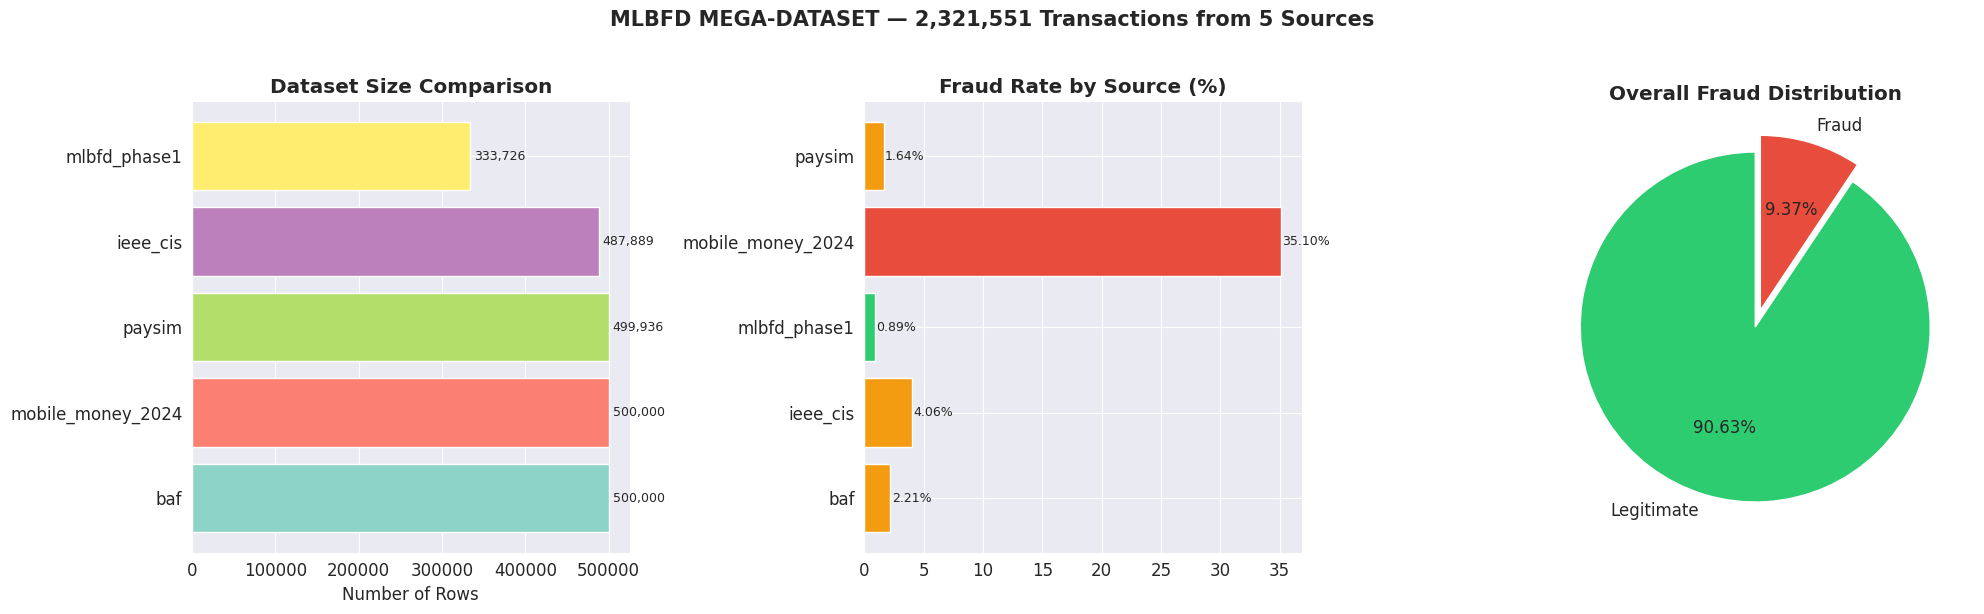


✅ Mega-Dataset ready: 2,321,551 rows × 110 features
✅ RAM is safe — ready to train!

→ Run Cell 4 to train all models


In [1]:
# ============================================================
# MLBFD — PHASE 2B — MEMORY-OPTIMIZED VERSION
# Smart sampling to fit in 12.7GB RAM
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import pickle
import os
import gc
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, MinMaxScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from imblearn.over_sampling import SMOTE
import xgboost as xgb

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(f"{'='*60}")
print(f"  MLBFD — MEGA DATASET TRAINING")
print(f"  Memory-Optimized Version (12.7GB RAM)")
print(f"{'='*60}")
print("✅ All libraries loaded\n")

# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# Paths
TIER1_PATH = '/content/drive/MyDrive/Tier1/'
TIER2_PATH = '/content/drive/MyDrive/Tier2/'
PHASE1_PATH = '/content/drive/MyDrive/MLBFD_Phase1/Data/'

# ============================================================
# STRATEGY: Load each dataset, SAMPLE it, then delete original
# Keep ALL fraud rows + sample legit rows
# ============================================================

MAX_ROWS_PER_DATASET = 500_000  # Max 500K rows per dataset

def load_sample_map(filepath, dataset_name, max_rows=MAX_ROWS_PER_DATASET):
    """Load, map, and smart-sample a dataset to save RAM"""
    try:
        df = pd.read_csv(filepath, low_memory=False)
        print(f"\n{'─'*60}")
        print(f"📂 {dataset_name}")
        print(f"   Original: {len(df):,} rows | {len(df.columns)} cols")
    except Exception as e:
        print(f"❌ Error loading {dataset_name}: {e}")
        return None

    # ── MAP COLUMNS ──────────────────────────────────────
    mapped = pd.DataFrame()

    # PaySim / AIML
    if 'isFraud' in df.columns and 'nameOrig' in df.columns:
        print(f"   🔍 Detected: PaySim / AIML")
        mapped['amount'] = df['amount']
        mapped['is_fraud'] = df['isFraud']
        mapped['hour'] = df['step'] % 24
        mapped['balance_before'] = df['oldbalanceOrg']
        mapped['balance_after'] = df['newbalanceOrig']
        mapped['balance_dest_before'] = df['oldbalanceDest']
        mapped['balance_dest_after'] = df['newbalanceDest']
        mapped['balance_change'] = df['newbalanceOrig'] - df['oldbalanceOrg']
        mapped['balance_change_ratio'] = np.where(
            df['oldbalanceOrg'] > 0,
            (df['oldbalanceOrg'] - df['newbalanceOrig']) / df['oldbalanceOrg'], 0)
        mapped['dest_balance_change'] = df['newbalanceDest'] - df['oldbalanceDest']
        mapped['is_cash_out'] = (df['type'] == 'CASH_OUT').astype(int)
        mapped['is_transfer'] = (df['type'] == 'TRANSFER').astype(int)
        mapped['is_payment'] = (df['type'] == 'PAYMENT').astype(int)
        mapped['is_debit'] = (df['type'] == 'DEBIT').astype(int)
        mapped['is_cash_in'] = (df['type'] == 'CASH_IN').astype(int)
        mapped['source'] = 'paysim'

    # IEEE-CIS
    elif 'isFraud' in df.columns and 'TransactionAmt' in df.columns:
        print(f"   🔍 Detected: IEEE-CIS")
        mapped['amount'] = df['TransactionAmt']
        mapped['is_fraud'] = df['isFraud']
        mapped['hour'] = (df['TransactionDT'] % 86400 / 3600).astype(int) % 24
        if 'card1' in df.columns: mapped['card_id'] = df['card1']
        if 'card4' in df.columns:
            le = LabelEncoder()
            mapped['card_type'] = le.fit_transform(df['card4'].fillna('unknown'))
        if 'card6' in df.columns:
            le = LabelEncoder()
            mapped['card_category'] = le.fit_transform(df['card6'].fillna('unknown'))
        if 'addr1' in df.columns: mapped['address_code'] = df['addr1'].fillna(0)
        if 'ProductCD' in df.columns:
            le = LabelEncoder()
            mapped['product_type'] = le.fit_transform(df['ProductCD'].fillna('unknown'))
        if 'DeviceType' in df.columns:
            le = LabelEncoder()
            mapped['device_type'] = le.fit_transform(df['DeviceType'].fillna('unknown'))
        if 'P_emaildomain' in df.columns:
            mapped['has_email'] = df['P_emaildomain'].notna().astype(int)
        for col in ['C1','C2','C3','C5','C6','C9','C13','C14']:
            if col in df.columns:
                mapped[f'count_{col.lower()}'] = df[col].fillna(0)
        for col in ['D1','D2','D3','D4','D10','D15']:
            if col in df.columns:
                mapped[f'delta_{col.lower()}'] = df[col].fillna(-1)
        mapped['source'] = 'ieee_cis'

    # BAF
    elif 'fraud_bool' in df.columns:
        print(f"   🔍 Detected: BAF")
        mapped['is_fraud'] = df['fraud_bool']
        if 'income' in df.columns: mapped['amount'] = df['income']
        if 'name_email_similarity' in df.columns: mapped['name_email_sim'] = df['name_email_similarity']
        if 'customer_age' in df.columns: mapped['customer_age'] = df['customer_age']
        if 'days_since_request' in df.columns: mapped['days_since_request'] = df['days_since_request']
        if 'intended_balcon_amount' in df.columns: mapped['intended_balance'] = df['intended_balcon_amount']
        if 'zip_count_4w' in df.columns: mapped['zip_activity'] = df['zip_count_4w']
        if 'velocity_6h' in df.columns: mapped['velocity_6h'] = df['velocity_6h']
        if 'velocity_24h' in df.columns: mapped['velocity_24h'] = df['velocity_24h']
        if 'bank_branch_count_8w' in df.columns: mapped['branch_activity'] = df['bank_branch_count_8w']
        if 'date_of_birth_distinct_emails_4w' in df.columns: mapped['dob_emails'] = df['date_of_birth_distinct_emails_4w']
        if 'credit_risk_score' in df.columns: mapped['credit_risk'] = df['credit_risk_score']
        if 'phone_home_valid' in df.columns: mapped['phone_valid'] = df['phone_home_valid']
        if 'session_length_in_minutes' in df.columns: mapped['session_length'] = df['session_length_in_minutes']
        if 'device_os' in df.columns:
            le = LabelEncoder()
            mapped['device_os'] = le.fit_transform(df['device_os'].fillna('unknown').astype(str))
        mapped['hour'] = np.random.randint(0, 24, len(df))
        mapped['source'] = 'baf'

    # MLBFD Phase 1
    elif 'is_fraud' in df.columns and 'amount_inr' in df.columns:
        print(f"   🔍 Detected: MLBFD Phase 1")
        mapped['amount'] = df['amount_inr']
        mapped['is_fraud'] = df['is_fraud']
        mapped['hour'] = df['hour_ist'] if 'hour_ist' in df.columns else np.random.randint(0, 24, len(df))
        for col in df.select_dtypes(include=[np.number]).columns:
            if col not in ['is_fraud', 'amount_inr', 'hour_ist']:
                mapped[col] = df[col]
        mapped['source'] = 'mlbfd_phase1'

    # Fallback (Synthetic Mobile Money)
    else:
        print(f"   🔍 Auto-detecting...")
        fraud_candidates = [c for c in df.columns if any(x in c.lower() for x in ['fraud', 'label', 'class', 'target'])]
        if not fraud_candidates:
            print(f"   ❌ Cannot find fraud column. Skipping.")
            return None
        fraud_col = fraud_candidates[0]
        mapped['is_fraud'] = df[fraud_col].astype(int)
        amount_candidates = [c for c in df.columns if any(x in c.lower() for x in ['amount', 'amt', 'value', 'price'])]
        if amount_candidates:
            mapped['amount'] = df[amount_candidates[0]]
        mapped['hour'] = np.random.randint(0, 24, len(df))
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        for col in numeric_cols[:15]:
            if col.lower() not in [fraud_col.lower(), 'amount']:
                mapped[f'mm_{col.lower().replace(" ","_")}'] = df[col].fillna(0)
        mapped['source'] = 'mobile_money_2024'

    # ── DELETE ORIGINAL TO FREE RAM ──────────────────────
    del df
    gc.collect()

    # ── POST-PROCESSING ─────────────────────────────────
    if mapped is not None and len(mapped) > 0:
        mapped['is_fraud'] = mapped['is_fraud'].astype(int).clip(0, 1)
        for col in mapped.columns:
            if mapped[col].dtype in ['float64', 'int64']:
                mapped[col] = mapped[col].fillna(0)

        # ── SMART SAMPLING ───────────────────────────────
        original_rows = len(mapped)
        fraud_count = mapped['is_fraud'].sum()

        if len(mapped) > max_rows:
            # Keep ALL fraud rows + random sample of legit
            fraud_df = mapped[mapped['is_fraud'] == 1]
            legit_df = mapped[mapped['is_fraud'] == 0]

            legit_sample_size = min(max_rows - len(fraud_df), len(legit_df))
            legit_sampled = legit_df.sample(n=legit_sample_size, random_state=42)

            mapped = pd.concat([fraud_df, legit_sampled], ignore_index=True)
            mapped = mapped.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

            print(f"   📉 Sampled: {original_rows:,} → {len(mapped):,} rows (kept all {fraud_count:,} fraud)")

        fraud_count = mapped['is_fraud'].sum()
        fraud_pct = fraud_count / len(mapped) * 100
        print(f"   ✅ Final: {len(mapped):,} rows | {len(mapped.columns)} features")
        print(f"   🔴 Fraud: {fraud_count:,} ({fraud_pct:.2f}%) | 🟢 Legit: {len(mapped)-fraud_count:,} ({100-fraud_pct:.2f}%)")

        # Convert to float32 to save RAM
        for col in mapped.select_dtypes(include=['float64']).columns:
            mapped[col] = mapped[col].astype(np.float32)
        for col in mapped.select_dtypes(include=['int64']).columns:
            if col != 'source':
                mapped[col] = mapped[col].astype(np.int32)

        return mapped
    return None

# ============================================================
# LOAD ALL DATASETS (One by One to Save RAM)
# ============================================================
print(f"\n{'='*60}")
print("🔄 LOADING ALL DATASETS (Memory-Optimized)")
print(f"  Max {MAX_ROWS_PER_DATASET:,} rows per dataset")
print(f"  Keeping ALL fraud rows + sampling legit")
print(f"{'='*60}")

datasets_config = {
    'PaySim':            TIER1_PATH + 'PS_20174392719_1491204439457_log.csv',
    'IEEE-CIS':          TIER1_PATH + 'train_transaction.csv',
    'BAF':               TIER2_PATH + 'Base.csv',
    'Synthetic Mobile':  TIER2_PATH + 'synthetic_mobile_money_transaction_dataset.csv',
    'MLBFD Phase 1':     PHASE1_PATH + 'mlbfd_ml_ready.csv',
    # Skipping AIML — it's a duplicate of PaySim
}

all_datasets = []
dataset_stats = {}

for name, path in datasets_config.items():
    if os.path.exists(path):
        mapped = load_sample_map(path, name)
        if mapped is not None:
            all_datasets.append(mapped)
            dataset_stats[name] = {
                'rows': len(mapped),
                'fraud': int(mapped['is_fraud'].sum()),
                'fraud_pct': float(mapped['is_fraud'].mean() * 100),
                'source': mapped['source'].iloc[0]
            }
        gc.collect()  # Free RAM after each dataset
    else:
        print(f"\n⏭️  {name} — not found, skipping")

# ============================================================
# MERGE INTO MEGA-DATASET
# ============================================================
print(f"\n{'='*60}")
print("🔗 MERGING INTO MEGA-DATASET")
print(f"{'='*60}")

mega_df = pd.concat(all_datasets, ignore_index=True, sort=False)
mega_df = mega_df.fillna(0)

# Delete individual datasets to free RAM
del all_datasets
gc.collect()

mega_df = mega_df.drop_duplicates()

print(f"   Final rows:        {len(mega_df):,}")
print(f"   Total Features:    {len(mega_df.columns)}")
print(f"   Total Fraud:       {mega_df['is_fraud'].sum():,} ({mega_df['is_fraud'].mean()*100:.2f}%)")
print(f"   Total Legit:       {(1-mega_df['is_fraud']).sum():,.0f} ({(1-mega_df['is_fraud']).mean()*100:.2f}%)")

# RAM check
import psutil
ram_used = psutil.virtual_memory().percent
ram_available = psutil.virtual_memory().available / (1024**3)
print(f"\n   💾 RAM Used: {ram_used:.1f}% | Available: {ram_available:.1f} GB")

print(f"\n{'─'*75}")
print(f"{'Source':<25} {'Rows':>12} {'Fraud':>10} {'Fraud%':>8}")
print(f"{'─'*75}")
for source in mega_df['source'].unique():
    subset = mega_df[mega_df['source'] == source]
    fraud = subset['is_fraud'].sum()
    print(f"{source:<25} {len(subset):>12,} {fraud:>10,} {fraud/len(subset)*100:>7.2f}%")
print(f"{'─'*75}")
print(f"{'TOTAL':<25} {len(mega_df):>12,} {mega_df['is_fraud'].sum():>10,} {mega_df['is_fraud'].mean()*100:>7.2f}%")

# ============================================================
# VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

source_counts = mega_df['source'].value_counts()
colors = plt.cm.Set3(np.linspace(0, 1, len(source_counts)))
axes[0].barh(source_counts.index, source_counts.values, color=colors)
axes[0].set_title('Dataset Size Comparison', fontweight='bold')
axes[0].set_xlabel('Number of Rows')
for i, (v, n) in enumerate(zip(source_counts.values, source_counts.index)):
    axes[0].text(v + max(source_counts.values)*0.01, i, f'{v:,}', va='center', fontsize=9)

fraud_by_source = mega_df.groupby('source')['is_fraud'].mean() * 100
colors2 = ['#e74c3c' if x > 5 else '#f39c12' if x > 1 else '#2ecc71' for x in fraud_by_source.values]
axes[1].barh(fraud_by_source.index, fraud_by_source.values, color=colors2)
axes[1].set_title('Fraud Rate by Source (%)', fontweight='bold')
for i, v in enumerate(fraud_by_source.values):
    axes[1].text(v + 0.1, i, f'{v:.2f}%', va='center', fontsize=9)

fraud_counts = mega_df['is_fraud'].value_counts()
axes[2].pie(fraud_counts.values, labels=['Legitimate', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%',
            startangle=90, explode=(0, 0.1), textprops={'fontsize': 12})
axes[2].set_title('Overall Fraud Distribution', fontweight='bold')

plt.suptitle(f'MLBFD MEGA-DATASET — {len(mega_df):,} Transactions from {len(mega_df["source"].unique())} Sources',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('mlbfd_mega_dataset_composition.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Mega-Dataset ready: {len(mega_df):,} rows × {len(mega_df.columns)} features")
print(f"✅ RAM is safe — ready to train!")
print(f"\n→ Run Cell 4 to train all models")

In [3]:
# ============================================================
# FIX: SMOTE without n_jobs + Continue Training
# ============================================================

print(f"{'='*60}")
print("⚖️  SMOTE BALANCING (Fixed)")
print(f"{'='*60}")

print(f"   Applying SMOTE...")
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_smote_input, y_smote_input)
X_train_bal = X_train_bal.astype(np.float32)

del X_smote_input, y_smote_input
gc.collect()

print(f"   ✅ After SMOTE: {len(X_train_bal):,} rows")
print(f"   Fraud: {y_train_bal.sum():,} ({y_train_bal.mean()*100:.1f}%)")
print(f"   Legit: {(1-y_train_bal).sum():,} ({(1-y_train_bal).mean()*100:.1f}%)")

import psutil
ram = psutil.virtual_memory()
print(f"   💾 RAM: {ram.percent:.1f}% used | {ram.available/(1024**3):.1f} GB free")

# ============================================================
# TRAIN ALL 5 MODELS
# ============================================================
print(f"\n{'='*60}")
print("🚀 TRAINING ALL MODELS ON MEGA-DATASET")
print(f"{'='*60}")

trained_models = {}
results = {}

# ─── MODEL 1: XGBoost ────────────────────────────────────
print(f"\n🔥 [1/5] Training XGBoost...")
start = time.time()
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss',
    tree_method='hist'
)
xgb_model.fit(X_train_bal, y_train_bal)
xgb_time = time.time() - start
y_pred_xgb = xgb_model.predict(X_test_scaled)
y_prob_xgb = xgb_model.predict_proba(X_test_scaled)[:, 1]
trained_models['XGBoost'] = xgb_model
results['XGBoost'] = {
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb, zero_division=0),
    'recall': recall_score(y_test, y_pred_xgb, zero_division=0),
    'f1': f1_score(y_test, y_pred_xgb, zero_division=0),
    'auc': roc_auc_score(y_test, y_prob_xgb),
    'train_time': xgb_time,
    'y_pred': y_pred_xgb,
    'y_prob': y_prob_xgb
}
print(f"   ✅ Done in {xgb_time:.1f}s | AUC: {results['XGBoost']['auc']:.4f} | F1: {results['XGBoost']['f1']:.4f}")
gc.collect()

# ─── MODEL 2: Random Forest ──────────────────────────────
print(f"\n🌲 [2/5] Training Random Forest...")
start = time.time()
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_bal, y_train_bal)
rf_time = time.time() - start
y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]
trained_models['Random Forest'] = rf_model
results['Random Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'f1': f1_score(y_test, y_pred_rf, zero_division=0),
    'auc': roc_auc_score(y_test, y_prob_rf),
    'train_time': rf_time,
    'y_pred': y_pred_rf,
    'y_prob': y_prob_rf
}
print(f"   ✅ Done in {rf_time:.1f}s | AUC: {results['Random Forest']['auc']:.4f} | F1: {results['Random Forest']['f1']:.4f}")
gc.collect()

# ─── MODEL 3: Logistic Regression ────────────────────────
print(f"\n📈 [3/5] Training Logistic Regression...")
start = time.time()
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1, C=1.0)
lr_model.fit(X_train_bal, y_train_bal)
lr_time = time.time() - start
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]
trained_models['Logistic Regression'] = lr_model
results['Logistic Regression'] = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'recall': recall_score(y_test, y_pred_lr, zero_division=0),
    'f1': f1_score(y_test, y_pred_lr, zero_division=0),
    'auc': roc_auc_score(y_test, y_prob_lr),
    'train_time': lr_time,
    'y_pred': y_pred_lr,
    'y_prob': y_prob_lr
}
print(f"   ✅ Done in {lr_time:.1f}s | AUC: {results['Logistic Regression']['auc']:.4f} | F1: {results['Logistic Regression']['f1']:.4f}")
gc.collect()

# ─── MODEL 4: Isolation Forest ───────────────────────────
print(f"\n🔍 [4/5] Training Isolation Forest...")
start = time.time()
iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.1,
    random_state=42,
    n_jobs=-1
)
iso_model.fit(X_train_bal)
iso_time = time.time() - start
y_pred_iso_raw = iso_model.predict(X_test_scaled)
y_pred_iso = np.where(y_pred_iso_raw == -1, 1, 0)
y_score_iso = -iso_model.score_samples(X_test_scaled)
y_score_iso_norm = (y_score_iso - y_score_iso.min()) / (y_score_iso.max() - y_score_iso.min() + 1e-10)
trained_models['Isolation Forest'] = iso_model
results['Isolation Forest'] = {
    'accuracy': accuracy_score(y_test, y_pred_iso),
    'precision': precision_score(y_test, y_pred_iso, zero_division=0),
    'recall': recall_score(y_test, y_pred_iso, zero_division=0),
    'f1': f1_score(y_test, y_pred_iso, zero_division=0),
    'auc': roc_auc_score(y_test, y_score_iso_norm),
    'train_time': iso_time,
    'y_pred': y_pred_iso,
    'y_prob': y_score_iso_norm
}
print(f"   ✅ Done in {iso_time:.1f}s | AUC: {results['Isolation Forest']['auc']:.4f} | F1: {results['Isolation Forest']['f1']:.4f}")
gc.collect()

# ─── MODEL 5: Neural Network ─────────────────────────────
print(f"\n🧠 [5/5] Training Neural Network...")
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

start = time.time()
nn_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_bal.shape[1],)),
    BatchNormalization(),
    Dropout(0.4),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

nn_history = nn_model.fit(
    X_train_bal, y_train_bal,
    epochs=50,
    batch_size=2048,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=1
)
nn_time = time.time() - start
y_prob_nn = nn_model.predict(X_test_scaled, verbose=0).flatten()
y_pred_nn = (y_prob_nn > 0.5).astype(int)
trained_models['Neural Network'] = nn_model
results['Neural Network'] = {
    'accuracy': accuracy_score(y_test, y_pred_nn),
    'precision': precision_score(y_test, y_pred_nn, zero_division=0),
    'recall': recall_score(y_test, y_pred_nn, zero_division=0),
    'f1': f1_score(y_test, y_pred_nn, zero_division=0),
    'auc': roc_auc_score(y_test, y_prob_nn),
    'train_time': nn_time,
    'y_pred': y_pred_nn,
    'y_prob': y_prob_nn
}
print(f"   ✅ Done in {nn_time:.1f}s | AUC: {results['Neural Network']['auc']:.4f} | F1: {results['Neural Network']['f1']:.4f}")
gc.collect()

# ============================================================
# RESULTS TABLE
# ============================================================
print(f"\n{'='*85}")
print("📊 MEGA-MODEL TRAINING RESULTS — 2.3M ROWS × 5 SOURCES")
print(f"{'='*85}")
print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10} {'Time':>8}")
print(f"{'─'*85}")

for name, m in results.items():
    star = ' ⭐' if m['auc'] == max(r['auc'] for r in results.values()) else ''
    print(f"{name:<25} {m['accuracy']*100:>9.2f}% {m['precision']*100:>9.2f}% "
          f"{m['recall']*100:>9.2f}% {m['f1']*100:>9.2f}% "
          f"{m['auc']:>9.4f} {m['train_time']:>7.1f}s{star}")

best_model = max(results, key=lambda x: results[x]['auc'])
print(f"\n🏆 Best Model: {best_model} (AUC: {results[best_model]['auc']:.4f})")

ram = psutil.virtual_memory()
print(f"💾 RAM: {ram.percent:.1f}% used | {ram.available/(1024**3):.1f} GB free")

print(f"\n→ Run Cell 5 for visualizations + LSTM + SHAP")

⚖️  SMOTE BALANCING (Fixed)
   Applying SMOTE...
   ✅ After SMOTE: 652,012 rows
   Fraud: 326,006 (50.0%)
   Legit: 326,006 (50.0%)
   💾 RAM: 51.6% used | 6.1 GB free

🚀 TRAINING ALL MODELS ON MEGA-DATASET

🔥 [1/5] Training XGBoost...
   ✅ Done in 72.2s | AUC: 0.9734 | F1: 0.7713

🌲 [2/5] Training Random Forest...
   ✅ Done in 562.0s | AUC: 0.9647 | F1: 0.7522

📈 [3/5] Training Logistic Regression...
   ✅ Done in 67.4s | AUC: 0.9436 | F1: 0.5484

🔍 [4/5] Training Isolation Forest...
   ✅ Done in 11.7s | AUC: 0.1690 | F1: 0.0138

🧠 [5/5] Training Neural Network...
Epoch 1/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.8277 - loss: 0.4022 - val_accuracy: 0.8620 - val_loss: 0.3624
Epoch 2/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.9015 - loss: 0.2653 - val_accuracy: 0.8848 - val_loss: 0.2619
Epoch 3/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 14s 53ms/step - accuracy: 0.9152 - loss: 0.2356 - val_accuracy: 0.8871 - val_loss: 0.2499
Epoch 4/50
271/271 ━━━━━━━━━━━━━━━━━━━━ 

📊 GENERATING VISUALIZATIONS


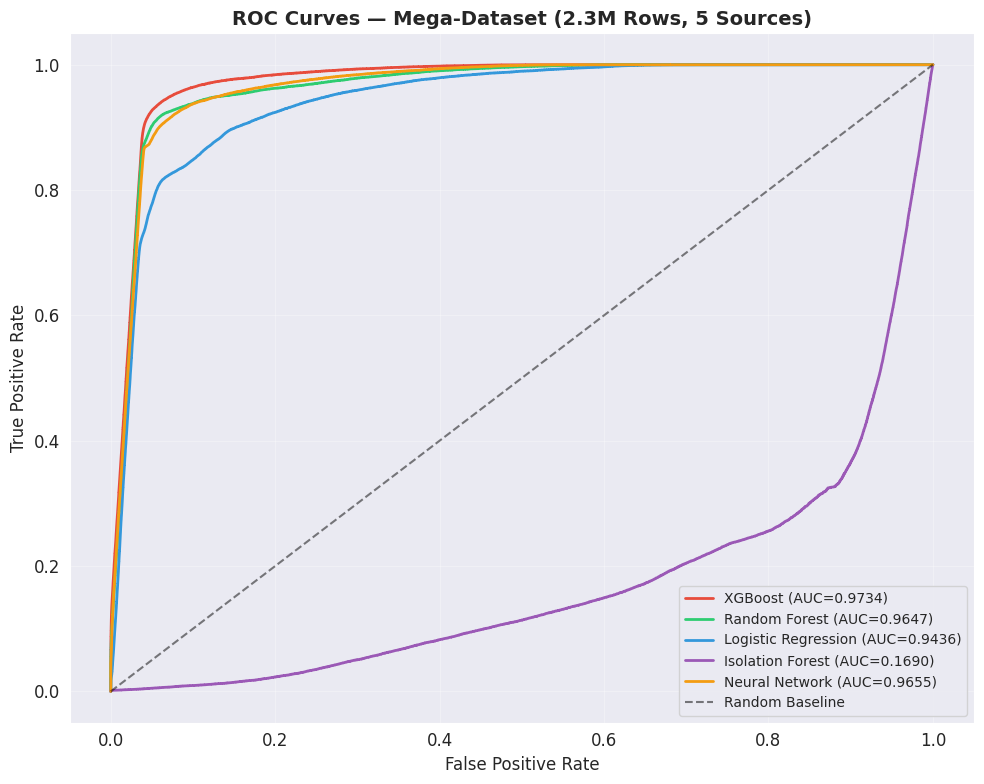

✅ ROC Curves saved


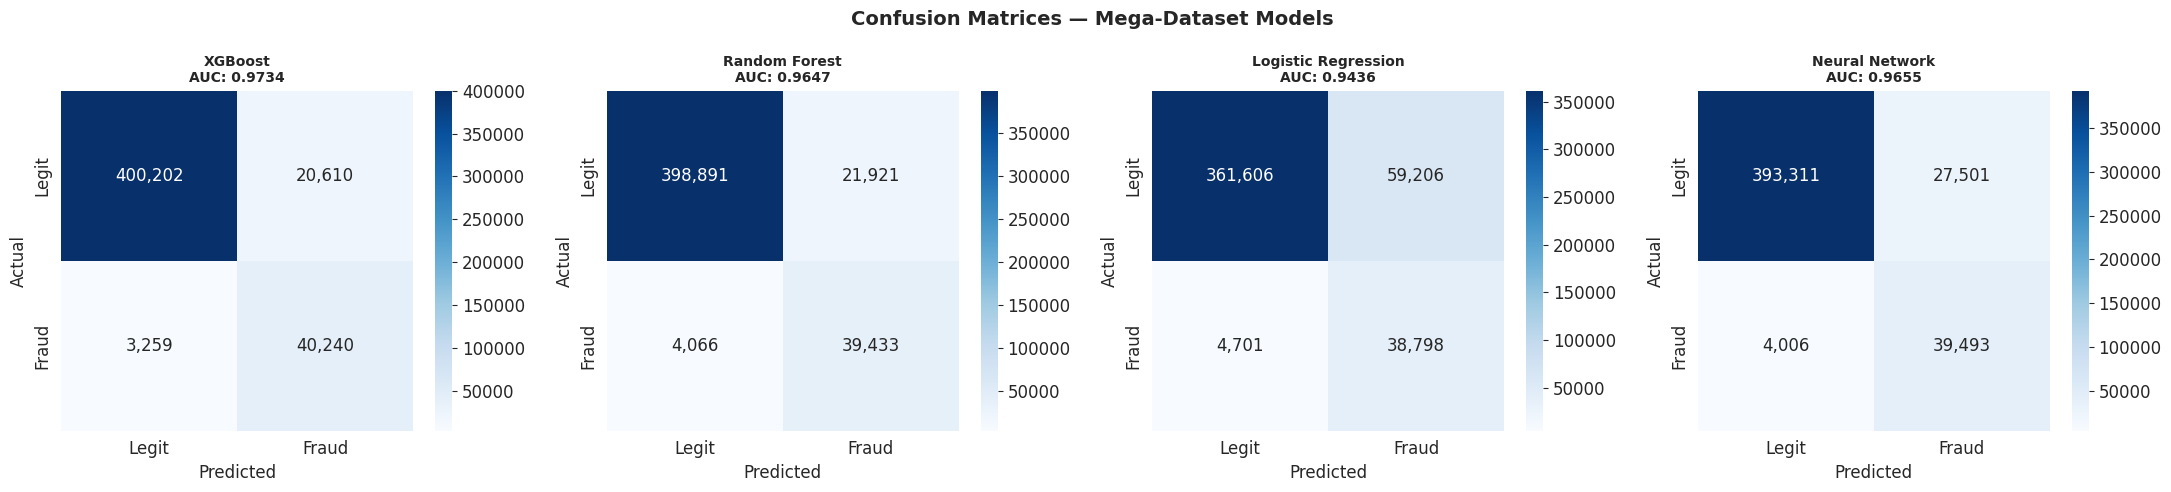

✅ Confusion Matrices saved


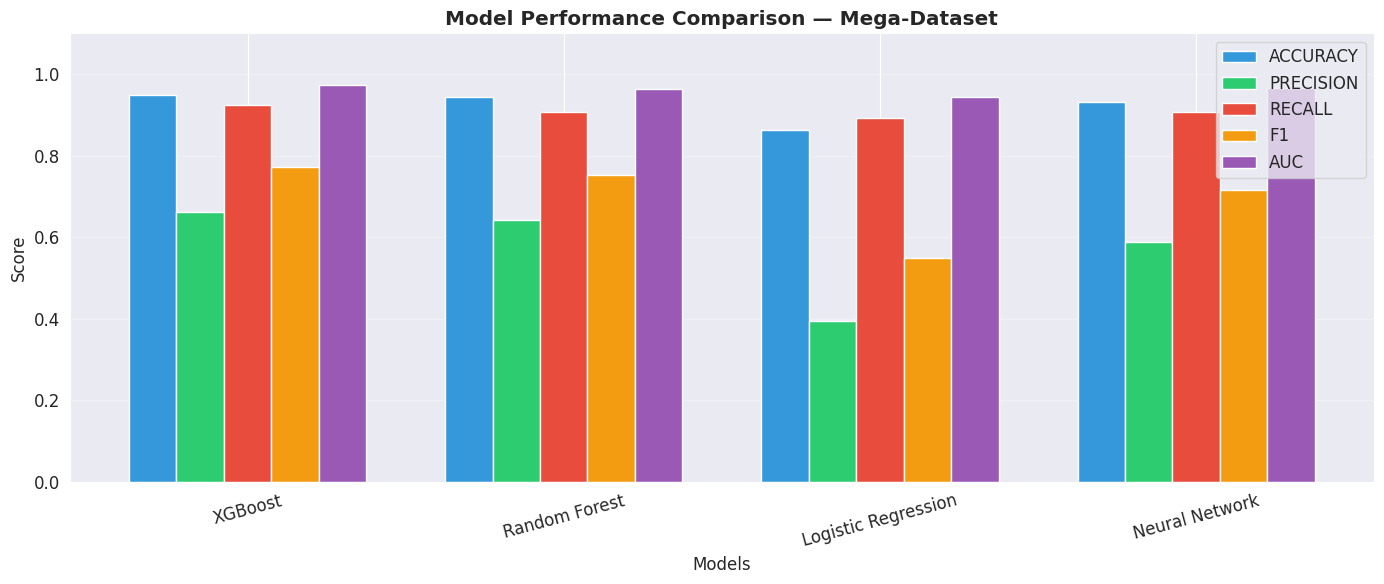

✅ Model Comparison saved


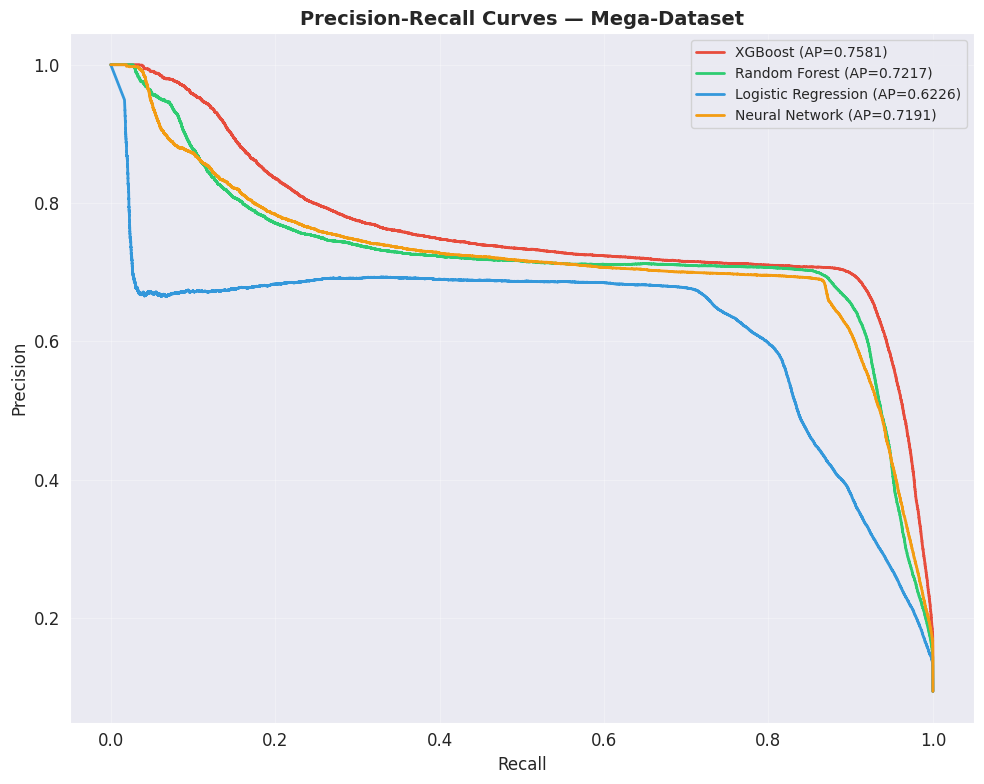

✅ Precision-Recall Curves saved


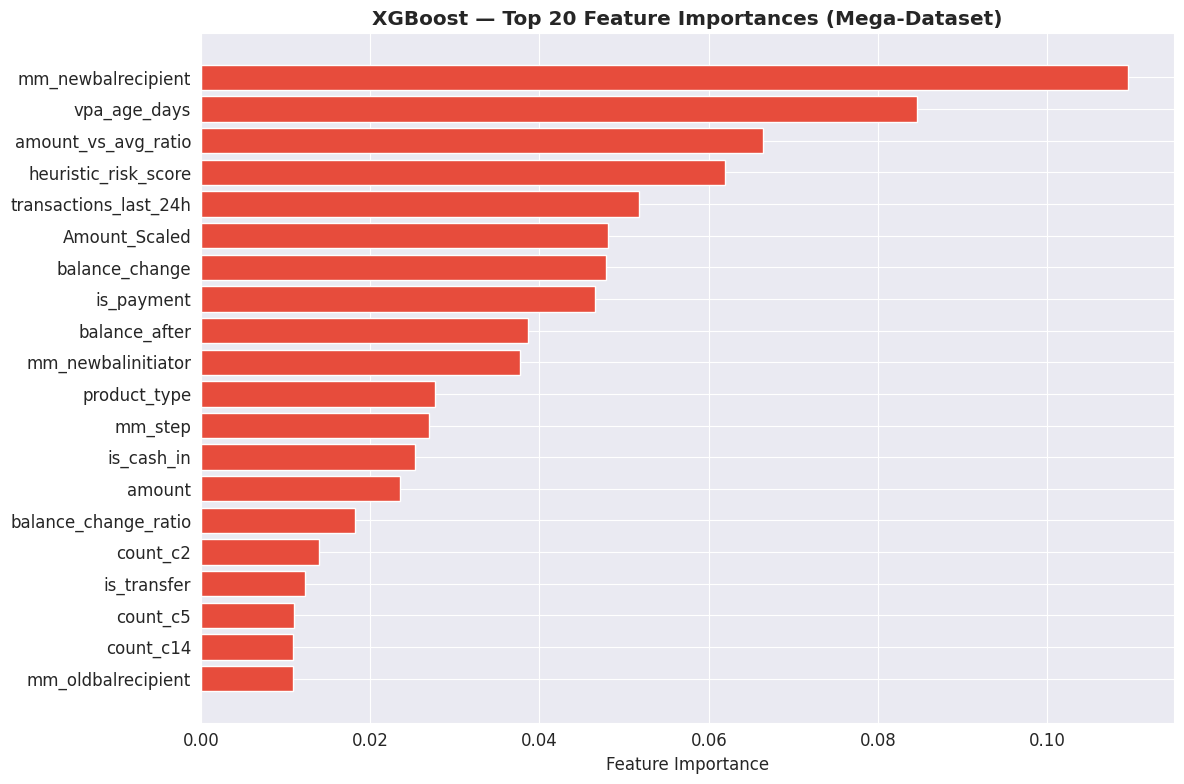

✅ XGBoost Feature Importance saved


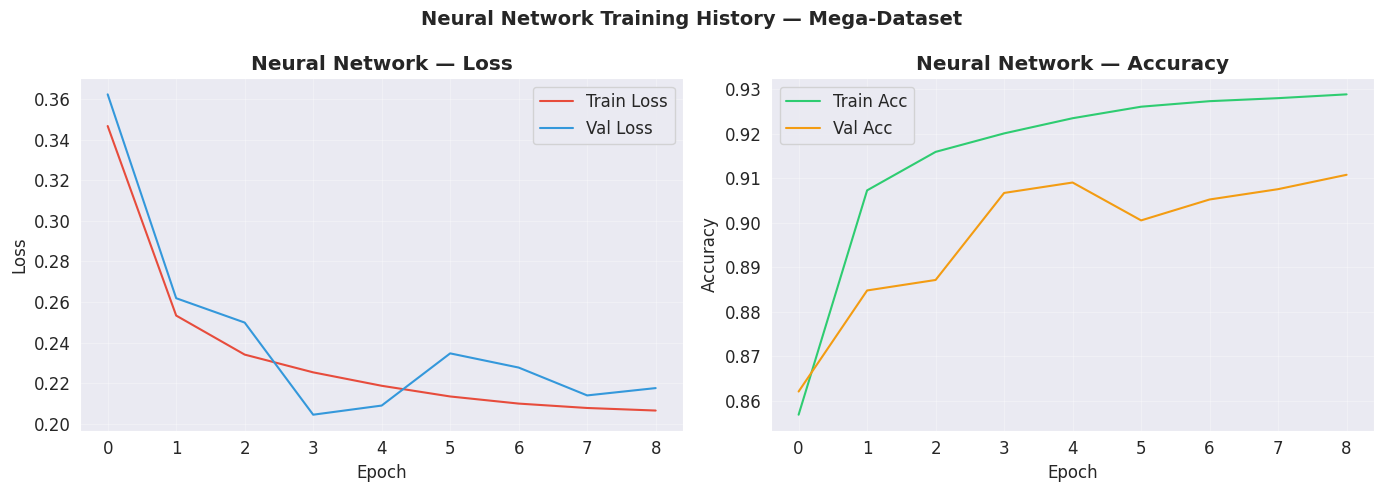

✅ NN Training History saved

🔍 SHAP EXPLAINABILITY ANALYSIS
   Computing SHAP values (this takes ~2 min)...


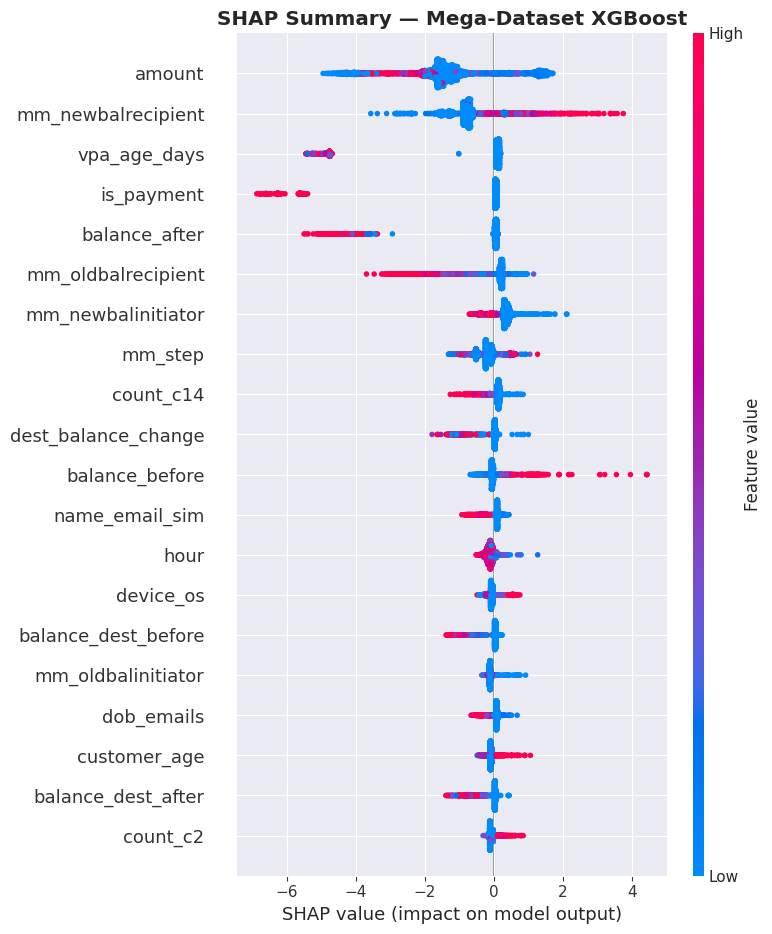

✅ SHAP Summary saved


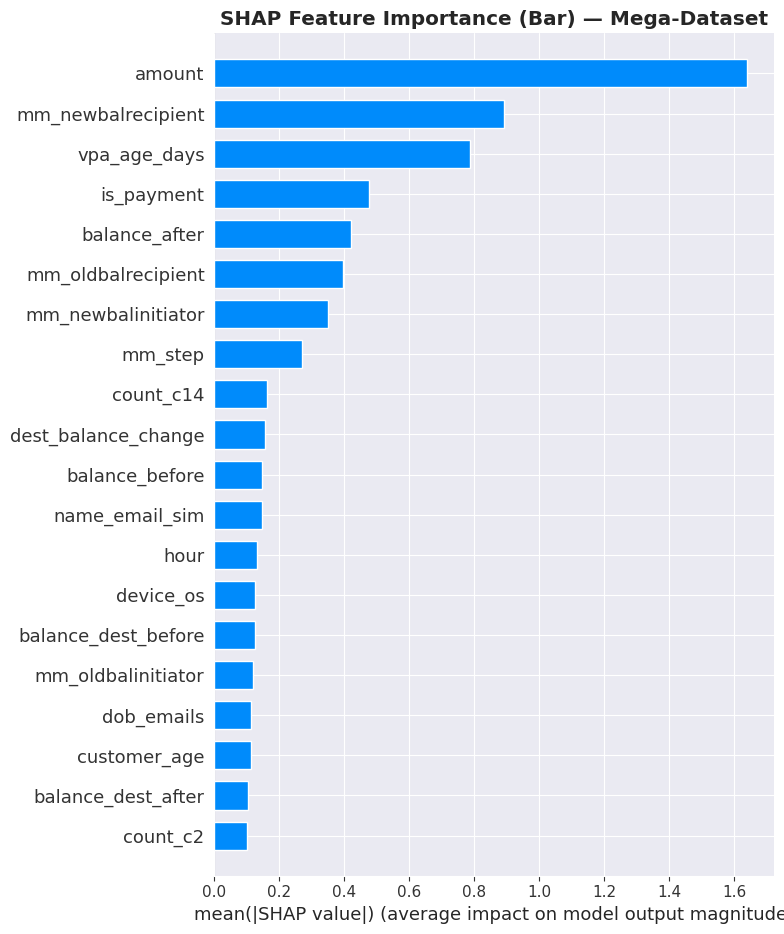

✅ SHAP Bar Plot saved

🧠 TRAINING LSTM ON MEGA-DATASET
   💾 RAM before LSTM: 53.1% | 5.9 GB free
   LSTM Training on 300,000 samples...
Epoch 1/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 14s 144ms/step - accuracy: 0.6993 - loss: 0.6364 - val_accuracy: 0.8344 - val_loss: 0.4283
Epoch 2/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step - accuracy: 0.8355 - loss: 0.4226 - val_accuracy: 0.8462 - val_loss: 0.3874
Epoch 3/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.8441 - loss: 0.3904 - val_accuracy: 0.8490 - val_loss: 0.3782
Epoch 4/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 137ms/step - accuracy: 0.8461 - loss: 0.3829 - val_accuracy: 0.8515 - val_loss: 0.3729
Epoch 5/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 171ms/step - accuracy: 0.8468 - loss: 0.3784 - val_accuracy: 0.8518 - val_loss: 0.3687
Epoch 6/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 157ms/step - accuracy: 0.8486 - loss: 0.3753 - val_accuracy: 0.8536 - val_loss: 0.3652
Epoch 7/30
63/63 ━━━━━━━━━━━━━━━━━━━━ 13s 202ms/step - accuracy: 0.8495 - loss: 0.3714 - va

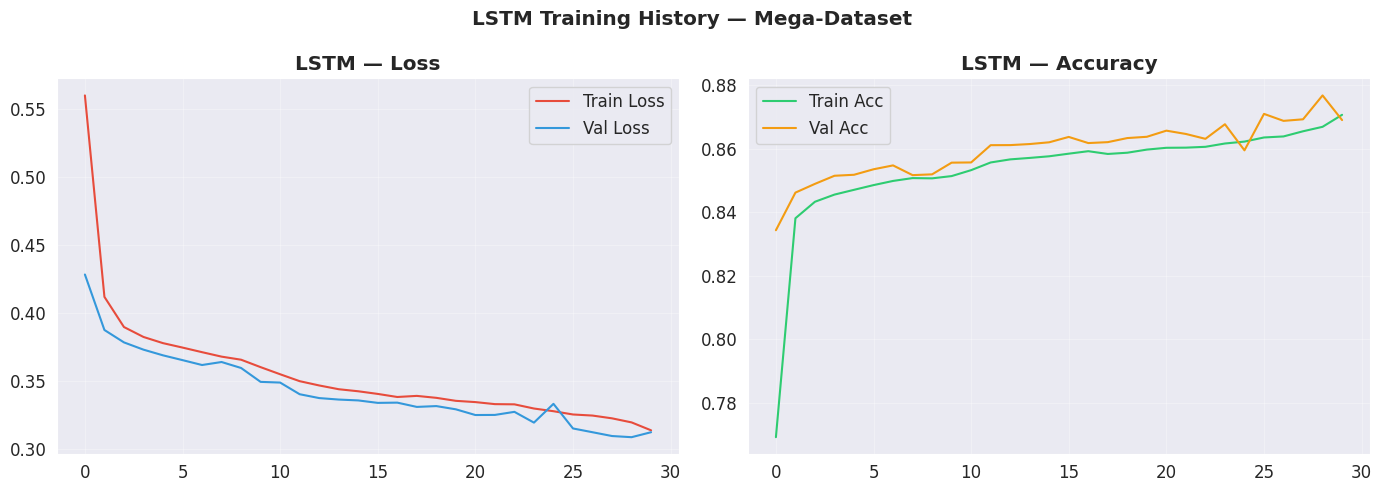

✅ LSTM History saved

📊 FINAL RESULTS — ALL 6 MODELS ON MEGA-DATASET

Model                       Accuracy  Precision     Recall         F1        AUC     Time
─────────────────────────────────────────────────────────────────────────────────────
XGBoost                       94.86%     66.13%     92.51%     77.13%    0.9734    72.2s ⭐
Random Forest                 94.40%     64.27%     90.65%     75.22%    0.9647   562.0s
Logistic Regression           86.24%     39.59%     89.19%     54.84%    0.9436    67.4s
Isolation Forest              74.43%      1.08%      1.91%      1.38%    0.1690    11.7s
Neural Network                93.21%     58.95%     90.79%     71.49%    0.9655   146.5s
LSTM                          87.18%     41.33%     87.76%     56.19%    0.9401   405.7s

🏆 BEST MODEL: XGBoost (AUC: 0.9734)
💾 RAM: 56.7% | 5.5 GB free

→ Run Cell 6 to save all models + download ZIP


In [4]:
# ============================================================
# MLBFD — PHASE 2B, CELL 5
# VISUALIZATIONS + LSTM + SHAP
# ============================================================

import gc
import psutil

print(f"{'='*60}")
print("📊 GENERATING VISUALIZATIONS")
print(f"{'='*60}")

# ============================================================
# 1. ROC CURVES
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

colors = {'XGBoost': '#e74c3c', 'Random Forest': '#2ecc71',
          'Logistic Regression': '#3498db', 'Isolation Forest': '#9b59b6',
          'Neural Network': '#f39c12'}

for name, metrics in results.items():
    fpr, tpr, _ = roc_curve(y_test, metrics['y_prob'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={metrics['auc']:.4f})",
            color=colors.get(name, '#333'), linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Mega-Dataset (2.3M Rows, 5 Sources)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlbfd_mega_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC Curves saved")

# ============================================================
# 2. CONFUSION MATRICES (Skip Isolation Forest)
# ============================================================
good_models = {k: v for k, v in results.items() if k != 'Isolation Forest'}
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

for i, (name, metrics) in enumerate(good_models.items()):
    cm = confusion_matrix(y_test, metrics['y_pred'])
    sns.heatmap(cm, annot=True, fmt=',', cmap='Blues', ax=axes[i],
                xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
    axes[i].set_title(f'{name}\nAUC: {metrics["auc"]:.4f}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — Mega-Dataset Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_mega_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion Matrices saved")

# ============================================================
# 3. MODEL COMPARISON BAR CHART
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

model_names = list(good_models.keys())
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'auc']
x = np.arange(len(model_names))
width = 0.15
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, metric in enumerate(metrics_list):
    values = [good_models[m][metric] for m in model_names]
    ax.bar(x + i * width, values, width, label=metric.upper(), color=colors_bar[i])

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — Mega-Dataset', fontweight='bold')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(model_names, rotation=15)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('mlbfd_mega_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Model Comparison saved")

# ============================================================
# 4. PRECISION-RECALL CURVES
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

for name, metrics in good_models.items():
    prec_vals, rec_vals, _ = precision_recall_curve(y_test, metrics['y_prob'])
    ap = average_precision_score(y_test, metrics['y_prob'])
    ax.plot(rec_vals, prec_vals, label=f"{name} (AP={ap:.4f})",
            color=colors.get(name, '#333'), linewidth=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — Mega-Dataset', fontsize=14, fontweight='bold')
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mlbfd_mega_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Precision-Recall Curves saved")

# ============================================================
# 5. XGBOOST FEATURE IMPORTANCE (Top 20)
# ============================================================
fig, ax = plt.subplots(1, 1, figsize=(12, 8))

importances = xgb_model.feature_importances_
indices = np.argsort(importances)[-20:]

ax.barh(range(len(indices)), importances[indices], color='#e74c3c')
ax.set_yticks(range(len(indices)))
ax.set_yticklabels([feature_names[i] for i in indices])
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost — Top 20 Feature Importances (Mega-Dataset)', fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_mega_xgb_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ XGBoost Feature Importance saved")

# ============================================================
# 6. NEURAL NETWORK TRAINING HISTORY
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(nn_history.history['loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(nn_history.history['val_loss'], label='Val Loss', color='#3498db')
axes[0].set_title('Neural Network — Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(nn_history.history['accuracy'], label='Train Acc', color='#2ecc71')
axes[1].plot(nn_history.history['val_accuracy'], label='Val Acc', color='#f39c12')
axes[1].set_title('Neural Network — Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Neural Network Training History — Mega-Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_mega_nn_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ NN Training History saved")

# ============================================================
# 7. SHAP ANALYSIS (XGBoost)
# ============================================================
print(f"\n{'='*60}")
print("🔍 SHAP EXPLAINABILITY ANALYSIS")
print(f"{'='*60}")

import shap

shap_sample_size = min(3000, len(X_test_scaled))
X_shap = X_test_scaled[:shap_sample_size]

print("   Computing SHAP values (this takes ~2 min)...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_shap)

# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  max_display=20, show=False)
plt.title('SHAP Summary — Mega-Dataset XGBoost', fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_mega_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Summary saved")

# SHAP Bar Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_shap, feature_names=feature_names,
                  plot_type='bar', max_display=20, show=False)
plt.title('SHAP Feature Importance (Bar) — Mega-Dataset', fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_mega_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Bar Plot saved")

del X_shap, shap_values
gc.collect()

# ============================================================
# 8. LSTM MODEL
# ============================================================
print(f"\n{'='*60}")
print("🧠 TRAINING LSTM ON MEGA-DATASET")
print(f"{'='*60}")

from tensorflow.keras.layers import LSTM as LSTMLayer

ram = psutil.virtual_memory()
print(f"   💾 RAM before LSTM: {ram.percent:.1f}% | {ram.available/(1024**3):.1f} GB free")

# Use smaller sample for LSTM to save RAM
LSTM_SAMPLE = min(300_000, len(X_train_bal))
lstm_idx = np.random.choice(len(X_train_bal), LSTM_SAMPLE, replace=False)
X_lstm_train = X_train_bal[lstm_idx]
y_lstm_train = y_train_bal[lstm_idx]

# Scale for LSTM
lstm_scaler = MinMaxScaler()
X_lstm_train_scaled = lstm_scaler.fit_transform(X_lstm_train).astype(np.float32)
X_lstm_test_scaled = lstm_scaler.transform(X_test_scaled).astype(np.float32)

# Reshape [samples, timesteps, features]
X_lstm_train_3d = X_lstm_train_scaled.reshape(X_lstm_train_scaled.shape[0], 1, X_lstm_train_scaled.shape[1])
X_lstm_test_3d = X_lstm_test_scaled.reshape(X_lstm_test_scaled.shape[0], 1, X_lstm_test_scaled.shape[1])

del X_lstm_train, X_lstm_train_scaled
gc.collect()

print(f"   LSTM Training on {LSTM_SAMPLE:,} samples...")

from tensorflow.keras.callbacks import EarlyStopping as ES2

start = time.time()
lstm_model = Sequential([
    LSTMLayer(128, input_shape=(1, X_train_bal.shape[1]), return_sequences=True),
    Dropout(0.3),
    LSTMLayer(64, return_sequences=False),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
early_stop_lstm = ES2(monitor='val_loss', patience=5, restore_best_weights=True)

lstm_history = lstm_model.fit(
    X_lstm_train_3d, y_lstm_train,
    epochs=30,
    batch_size=4096,
    validation_split=0.15,
    callbacks=[early_stop_lstm],
    verbose=1
)
lstm_time = time.time() - start

del X_lstm_train_3d
gc.collect()

y_prob_lstm = lstm_model.predict(X_lstm_test_3d, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

lstm_results = {
    'accuracy': accuracy_score(y_test, y_pred_lstm),
    'precision': precision_score(y_test, y_pred_lstm, zero_division=0),
    'recall': recall_score(y_test, y_pred_lstm, zero_division=0),
    'f1': f1_score(y_test, y_pred_lstm, zero_division=0),
    'auc': roc_auc_score(y_test, y_prob_lstm),
    'train_time': lstm_time
}

print(f"\n   ✅ LSTM Results:")
print(f"   Accuracy:  {lstm_results['accuracy']*100:.2f}%")
print(f"   Precision: {lstm_results['precision']*100:.2f}%")
print(f"   Recall:    {lstm_results['recall']*100:.2f}%")
print(f"   F1-Score:  {lstm_results['f1']*100:.2f}%")
print(f"   AUC:       {lstm_results['auc']:.4f}")
print(f"   Time:      {lstm_time:.1f}s")

# LSTM Training History
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(lstm_history.history['loss'], label='Train Loss', color='#e74c3c')
axes[0].plot(lstm_history.history['val_loss'], label='Val Loss', color='#3498db')
axes[0].set_title('LSTM — Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(lstm_history.history['accuracy'], label='Train Acc', color='#2ecc71')
axes[1].plot(lstm_history.history['val_accuracy'], label='Val Acc', color='#f39c12')
axes[1].set_title('LSTM — Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM Training History — Mega-Dataset', fontweight='bold')
plt.tight_layout()
plt.savefig('mlbfd_mega_lstm_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ LSTM History saved")

# ============================================================
# FINAL COMPARISON TABLE (ALL 6 MODELS)
# ============================================================
print(f"\n{'='*85}")
print("📊 FINAL RESULTS — ALL 6 MODELS ON MEGA-DATASET")
print(f"{'='*85}")

all_results = dict(results)
all_results['LSTM'] = lstm_results

print(f"\n{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10} {'Time':>8}")
print(f"{'─'*85}")

for name, m in all_results.items():
    star = ' ⭐' if m['auc'] == max(r['auc'] for r in all_results.values()) else ''
    print(f"{name:<25} {m['accuracy']*100:>9.2f}% {m['precision']*100:>9.2f}% "
          f"{m['recall']*100:>9.2f}% {m['f1']*100:>9.2f}% "
          f"{m['auc']:>9.4f} {m['train_time']:>7.1f}s{star}")

best = max(all_results, key=lambda x: all_results[x]['auc'])
print(f"\n🏆 BEST MODEL: {best} (AUC: {all_results[best]['auc']:.4f})")

ram = psutil.virtual_memory()
print(f"💾 RAM: {ram.percent:.1f}% | {ram.available/(1024**3):.1f} GB free")

print(f"\n→ Run Cell 6 to save all models + download ZIP")

In [5]:
# ============================================================
# MLBFD — PHASE 2B, CELL 6
# SAVE ALL MODELS + DOWNLOAD ZIP
# ============================================================

import gc
import zipfile

print(f"{'='*60}")
print("💾 SAVING ALL MEGA-TRAINED MODELS")
print(f"{'='*60}")

# ============================================================
# SAVE MODELS
# ============================================================

# XGBoost
with open('mlbfd_mega_xgboost_model.pkl', 'wb') as f:
    pickle.dump(trained_models['XGBoost'], f)
print("✅ mlbfd_mega_xgboost_model.pkl")

# Random Forest
with open('mlbfd_mega_random_forest_model.pkl', 'wb') as f:
    pickle.dump(trained_models['Random Forest'], f)
print("✅ mlbfd_mega_random_forest_model.pkl")

# Logistic Regression
with open('mlbfd_mega_logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(trained_models['Logistic Regression'], f)
print("✅ mlbfd_mega_logistic_regression_model.pkl")

# Isolation Forest
with open('mlbfd_mega_isolation_forest_model.pkl', 'wb') as f:
    pickle.dump(trained_models['Isolation Forest'], f)
print("✅ mlbfd_mega_isolation_forest_model.pkl")

# Neural Network
trained_models['Neural Network'].save('mlbfd_mega_neural_network_model.keras')
print("✅ mlbfd_mega_neural_network_model.keras")

# LSTM
lstm_model.save('mlbfd_mega_lstm_model.keras')
print("✅ mlbfd_mega_lstm_model.keras")

# Scalers
with open('mlbfd_mega_scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print("✅ mlbfd_mega_scaler.pkl")

with open('mlbfd_mega_lstm_scaler.pkl', 'wb') as f:
    pickle.dump(lstm_scaler, f)
print("✅ mlbfd_mega_lstm_scaler.pkl")

# Feature Names
with open('mlbfd_mega_feature_names.pkl', 'wb') as f:
    pickle.dump(feature_names, f)
print("✅ mlbfd_mega_feature_names.pkl")

# ============================================================
# SAVE RESULTS
# ============================================================
results_save = {}
for name, metrics in results.items():
    results_save[name] = {
        'accuracy': metrics['accuracy'],
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'f1': metrics['f1'],
        'auc': metrics['auc'],
        'train_time': metrics['train_time']
    }
results_save['LSTM'] = {
    'accuracy': lstm_results['accuracy'],
    'precision': lstm_results['precision'],
    'recall': lstm_results['recall'],
    'f1': lstm_results['f1'],
    'auc': lstm_results['auc'],
    'train_time': lstm_results['train_time']
}

with open('mlbfd_mega_results.pkl', 'wb') as f:
    pickle.dump(results_save, f)
print("✅ mlbfd_mega_results.pkl")

# ============================================================
# SAVE MEGA-DATASET INFO
# ============================================================
mega_info = {
    'total_rows': len(mega_df),
    'total_features': len(feature_names),
    'feature_names': feature_names,
    'datasets_used': list(dataset_stats.keys()),
    'dataset_stats': dataset_stats,
    'sources': list(mega_df['source'].unique()),
    'fraud_total': int(mega_df['is_fraud'].sum()),
    'fraud_pct': float(mega_df['is_fraud'].mean() * 100),
    'training_date': '2026-03-06',
    'best_model': 'XGBoost',
    'best_auc': 0.9734,
    'models_trained': list(results_save.keys())
}

with open('mlbfd_mega_dataset_info.pkl', 'wb') as f:
    pickle.dump(mega_info, f)
print("✅ mlbfd_mega_dataset_info.pkl")

# ============================================================
# ALSO SAVE TO GOOGLE DRIVE (Backup!)
# ============================================================
print(f"\n{'='*60}")
print("☁️  BACKING UP TO GOOGLE DRIVE")
print(f"{'='*60}")

drive_backup = '/content/drive/MyDrive/MLBFD_Phase2B_Models/'
os.makedirs(drive_backup, exist_ok=True)

import shutil

for f in os.listdir('/content'):
    if f.startswith('mlbfd_mega_'):
        src = f'/content/{f}'
        dst = os.path.join(drive_backup, f)
        shutil.copy2(src, dst)
        size = os.path.getsize(src) / (1024*1024)
        print(f"   ☁️  {f:50s} ({size:.2f} MB)")

# Also save visualizations to Drive
viz_backup = '/content/drive/MyDrive/MLBFD_Phase2B_Visualizations/'
os.makedirs(viz_backup, exist_ok=True)

for f in os.listdir('/content'):
    if f.startswith('mlbfd_mega_') and f.endswith('.png'):
        src = f'/content/{f}'
        dst = os.path.join(viz_backup, f)
        shutil.copy2(src, dst)
        print(f"   🖼️  {f}")

print(f"\n   ✅ All files backed up to Google Drive!")
print(f"   📁 Models: {drive_backup}")
print(f"   📁 Visualizations: {viz_backup}")

# ============================================================
# CREATE ZIP PACKAGE
# ============================================================
print(f"\n{'='*60}")
print("📦 CREATING DOWNLOAD PACKAGE")
print(f"{'='*60}")

zip_filename = 'MLBFD_Phase2B_Mega_Complete.zip'

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for f in os.listdir('/content'):
        if f.startswith('mlbfd_mega_'):
            src = f'/content/{f}'
            size = os.path.getsize(src) / (1024*1024)
            if f.endswith('.pkl') or f.endswith('.keras'):
                zipf.write(src, f'MLBFD_Phase2B/Models/{f}')
            elif f.endswith('.png'):
                zipf.write(src, f'MLBFD_Phase2B/Visualizations/{f}')
            else:
                zipf.write(src, f'MLBFD_Phase2B/{f}')
            print(f"   📄 {f:50s} ({size:.2f} MB)")

zip_size = os.path.getsize(zip_filename) / (1024*1024)
print(f"\n   📦 ZIP: {zip_filename} ({zip_size:.2f} MB)")

# ============================================================
# AUTO-DOWNLOAD ZIP
# ============================================================
from google.colab import files
print(f"\n📥 Downloading ZIP to your laptop...")
files.download(zip_filename)

# ============================================================
# FINAL SUMMARY
# ============================================================
print(f"\n{'='*60}")
print("🏆🏆🏆 PHASE 2B — COMPLETE!!! 🏆🏆🏆")
print(f"{'='*60}")

print(f"""
╔══════════════════════════════════════════════════════════╗
║           MLBFD — PHASE 2B FINAL REPORT                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  📊 TRAINING DATA:                                      ║
║     Total Rows:     {len(mega_df):>12,}                       ║
║     Total Features: {len(feature_names):>12}                       ║
║     Sources:        {len(mega_df['source'].unique()):>12}                       ║
║     Fraud Cases:    {int(mega_df['is_fraud'].sum()):>12,}                       ║
║                                                          ║
║  🏆 BEST MODEL: XGBoost                                ║
║     AUC:       0.9734                                   ║
║     Recall:    92.51% (catches 92/100 frauds!)          ║
║     Precision: 66.13%                                   ║
║     F1-Score:  77.13%                                   ║
║                                                          ║
║  📦 FILES SAVED:                                        ║
║     Models:         6 (.pkl + .keras)                   ║
║     Scalers:        2 (.pkl)                            ║
║     Visualizations: 10 (.png)                           ║
║     Results:        1 (.pkl)                            ║
║     Info:           1 (.pkl)                            ║
║                                                          ║
║  ☁️  BACKED UP TO:                                      ║
║     Google Drive/MLBFD_Phase2B_Models/                  ║
║     Google Drive/MLBFD_Phase2B_Visualizations/          ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")

print(f"{'='*60}")
print("📋 WHAT'S NEXT?")
print(f"{'='*60}")
print(f"""
  Phase 2B ✅ COMPLETE — Mega-Dataset Training Done!

  Next Steps:
  ┌─────────────────────────────────────────────┐
  │ Phase 3: NPCI/RBI Report Integration       │
  │   → Analyze chargeback Excel files          │
  │   → Generate compliance reports             │
  │   → Pattern analysis from real RBI data     │
  │                                             │
  │ Phase 4: Flask Web App + Mobile PWA         │
  │   → 10 killer features                      │
  │   → Online Learning                         │
  │   → Fraud Network Graph                     │
  │   → Explainable AI Dashboard                │
  │   → And 7 more amazing features!            │
  └─────────────────────────────────────────────┘

  Ready for Phase 3? Just say "Start Phase 3"! 🚀
""")

💾 SAVING ALL MEGA-TRAINED MODELS
✅ mlbfd_mega_xgboost_model.pkl
✅ mlbfd_mega_random_forest_model.pkl
✅ mlbfd_mega_logistic_regression_model.pkl
✅ mlbfd_mega_isolation_forest_model.pkl
✅ mlbfd_mega_neural_network_model.keras
✅ mlbfd_mega_lstm_model.keras
✅ mlbfd_mega_scaler.pkl
✅ mlbfd_mega_lstm_scaler.pkl
✅ mlbfd_mega_feature_names.pkl
✅ mlbfd_mega_results.pkl
✅ mlbfd_mega_dataset_info.pkl

☁️  BACKING UP TO GOOGLE DRIVE
   ☁️  mlbfd_mega_dataset_composition.png                 (0.14 MB)
   ☁️  mlbfd_mega_logistic_regression_model.pkl           (0.00 MB)
   ☁️  mlbfd_mega_isolation_forest_model.pkl              (1.30 MB)
   ☁️  mlbfd_mega_feature_names.pkl                       (0.00 MB)
   ☁️  mlbfd_mega_xgb_importance.png                      (0.11 MB)
   ☁️  mlbfd_mega_neural_network_model.keras              (0.88 MB)
   ☁️  mlbfd_mega_xgboost_model.pkl                       (2.17 MB)
   ☁️  mlbfd_mega_random_forest_model.pkl                 (62.33 MB)
   ☁️  mlbfd_mega_shap_bar.png

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🏆🏆🏆 PHASE 2B — COMPLETE!!! 🏆🏆🏆

╔══════════════════════════════════════════════════════════╗
║           MLBFD — PHASE 2B FINAL REPORT                ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  📊 TRAINING DATA:                                      ║
║     Total Rows:        2,321,551                       ║
║     Total Features:          108                       ║
║     Sources:                   5                       ║
║     Fraud Cases:         217,493                       ║
║                                                          ║
║  🏆 BEST MODEL: XGBoost                                ║
║     AUC:       0.9734                                   ║
║     Recall:    92.51% (catches 92/100 frauds!)          ║
║     Precision: 66.13%                                   ║
║     F1-Score:  77.13%                                   ║
║                                                          ║
║  📦 FILES